In [1]:
%load_ext autoreload
%autoreload 2


import numpy as np
import matplotlib
matplotlib.use('Agg')
import warnings
import pandas as pd
from datetime import datetime
from matplotlib import pyplot as plt
import seaborn as sns
from plotnine import *
import statsmodels.formula.api as smf


#Set random seeds
seed = 210226
warnings.filterwarnings('ignore', category=RuntimeWarning)

sns.set_theme(style="white", font_scale=1.2)

In [2]:
#####-------FILENAMES ETC--------------
dataset_name = "bch" 
raw_file_name = "preprocessed-visits-with-raw-variables"
load_filepath = "/Users/helenacoggan/mnt/chip-lacava-e2/Groups/BCH-ED/epi-and-prediction/"
save_filepath = "/Users/helenacoggan/mnt/chip-lacava-e2/Groups/ch265493/BCH-ED/decompensation/"
split_filepath = "/Users/helenacoggan/mnt/chip-lacava-e2/Groups/BCH-ED/epi-and-prediction/prediction/recent-eval/at-triage/"

raw_filepath = "/Users/helenacoggan/mnt/chip-lacava-e2/Groups/BCH-ED/raw-data/"


####--------PREPROCESSING VARIABLES------------

#Define identifier columns.
identifier_cols = ["csn", "is_admitted", "mrn", "minutes_since_first_arrival", "raw_arrival_month", "raw_arrival_year"]

#Define excluded columns-- we do not use these as predictors.
excluded_columns = identifier_cols + ["group", "assigned_order"] #These are excluded from both predictions and IPW calculations.
excluded_prefixes = ['current_diagnosis'] #These are excluded from just predictions.

#Identify gendered predictions; we exclude these when matching patients across sex-based groups
gendered_predictors = ['current_diagnosis_menstrual_disorders', 'pre_diagnosis_menstrual_disorders', 'complaint_contains_abdominal_pain',
                       'complaint_contains_gynecologic', 'complaint_contains_male_genital', 'complaint_contains_pregnancy']

#Separate categorical, pre-binarised, and continuous predictors.
categorical_predictors = [
    'race', 'sex', 'ed_arrival_mode', 'language',
                'insurance', 'home_state', 'year_of_arrival', 'season', 'time_of_day', 'triage_acuity']



#Variables which already 'come pre-binarised'.
pre_binarised_predictors = ['is_trans_or_nb', 'is_weekend',
                            'current_diagnosis_epilepsy', 'current_diagnosis_asthma', 'current_diagnosis_congenital_malformations', 
                'current_diagnosis_depression', 'current_diagnosis_pain_conditions', 'current_diagnosis_anxiety',
                  'current_diagnosis_conduct_disorders', 'current_diagnosis_nausea_and_vomiting',
                    'current_diagnosis_any_malignancy', 'current_diagnosis_gastrointestinal', 
                    'current_diagnosis_developmental_delays', 'current_diagnosis_psychotic_disorders', 
                    'current_diagnosis_cardiovascular', 'current_diagnosis_diabetes_mellitus', 'current_diagnosis_eating_disorders', 
                    'current_diagnosis_weight_loss', 'current_diagnosis_anemia', 'current_diagnosis_chromosomal_anomalies', 
                    'current_diagnosis_drug_abuse', 'current_diagnosis_menstrual_disorders', 'current_diagnosis_sleep_disorders', 
                    'current_diagnosis_smoking', 'current_diagnosis_alcohol_abuse', 'current_diagnosis_joint_disorders', 
                      'pre_diagnosis_any_malignancy', 'pre_diagnosis_gastrointestinal', 'pre_diagnosis_nausea_and_vomiting', 
                      'pre_diagnosis_diabetes_mellitus', 'pre_diagnosis_pain_conditions', 'pre_diagnosis_cardiovascular',
                        'pre_diagnosis_developmental_delays', 'pre_diagnosis_epilepsy', 'pre_diagnosis_asthma', 'pre_diagnosis_anemia', 
                        'pre_diagnosis_congenital_malformations', 'pre_diagnosis_conduct_disorders', 'pre_diagnosis_chromosomal_anomalies',
                          'pre_diagnosis_anxiety', 'pre_diagnosis_weight_loss', 'pre_diagnosis_psychotic_disorders', 'pre_diagnosis_drug_abuse',
                            'pre_diagnosis_smoking', 'pre_diagnosis_depression', 'pre_diagnosis_eating_disorders', 'pre_diagnosis_menstrual_disorders', 
                            'pre_diagnosis_sleep_disorders', 'pre_diagnosis_joint_disorders', 'pre_diagnosis_alcohol_abuse', 
                            'complaint_contains_abdominal_pain', 'complaint_contains_assault', 
                            'complaint_contains_allergic_reaction', 'complaint_contains_altered_mental_status',
                              'complaint_contains_asthma_or_wheezing', 'complaint_contains_bites_or_stings', 
                              'complaint_contains_burn', 'complaint_contains_cardiac', 'complaint_contains_chest_pain', 
                              'complaint_contains_chronic_disease', 'complaint_contains_congestion', 'complaint_contains_constipation', 
                              'complaint_contains_cough', 'complaint_contains_croup', 'complaint_contains_crying_or_colic', 'complaint_contains_dental', 
                              'complaint_contains_device_complication', 'complaint_contains_diarrhea', 'complaint_contains_ear_complaint',
                                'complaint_contains_epistaxis', 'complaint_contains_extremity', 'complaint_contains_eye_complaint', 
                                'complaint_contains_syncope', 'complaint_contains_foreign_body', 'complaint_contains_fever', 
                                'complaint_contains_follow_up', 'complaint_contains_general', 'complaint_contains_gi_bleed',
                                  'complaint_contains_gynecologic', 'complaint_contains_head_or_neck', 'complaint_contains_headache', 
                                  'complaint_contains_laceration', 'complaint_contains_lump_or_mass', 'complaint_contains_male_genital', 
                                  'complaint_contains_mvc', 'complaint_contains_neck_pain', 'complaint_contains_neurologic', 
                                  'complaint_contains_poisoning', 'complaint_contains_poor_feeding', 'complaint_contains_pregnancy', 
                                  'complaint_contains_primary_care', 'complaint_contains_psych', 'complaint_contains_rash', 
                                  'complaint_contains_other_respiratory', 'complaint_contains_seizure', 'complaint_contains_sore_throat',
                                    'complaint_contains_trauma', 'complaint_contains_urinary', 'complaint_contains_vomiting',
                    ]


#Continuous predictors.
continuous_predictors = [
    'age_in_days', 'miles_travelled', 'sdi_score',
     'crowdedness',  'raw_weight', 
     'num_previous_admissions', 'num_previous_visits_without_admission',
     'raw_triage_dbp', 'raw_triage_hr', 'raw_triage_pain', 'raw_triage_rr', 'raw_triage_sbp', 'raw_triage_sp_o2',
]



#Map races into groups.
race_dict = {
    'Hispanic': 'H',
    'Hispanic White': 'H',
    'Black': 'NHB',
    'Non-Hispanic Black': 'NHB',
    'Asian' : 'Other',
    'Unknown': 'Other',
    'Other': 'Other',
    'White': 'NHW',
    'Non-Hispanic White' : 'NHW'
}




Try to fit a model of individual ED LOS based on their own triage acuity and the triage acuity of those around them. For this, we need a sense of the burden at every arrival point. 

In [93]:
#Load the visits for these projects.
visits = pd.read_csv(save_filepath + 'intermediate-files/visits.csv', index_col=0)


#Classify visits into urgent and non-urgent. (Assume that everyone with no recorded triage acuity is non-urgent).
visits['urgent'] = ((~visits['triage_acuity'].isna()) & ((visits['triage_acuity'] == 1) | (visits['triage_acuity'] == 2))).astype(int)

#Now all we need is the admission status, urgency status, ED LOS and timeline of arrival.
visit_timeline = visits[['csn', 'urgent', 'is_admitted', 'ed_los', 'minutes_since_first_arrival']].copy().sort_values('minutes_since_first_arrival')

#So we need to keep a running count of how many urgent, non-urgent, admitted and non-admitted patients (that's a 4-way contingency table) there are in the ED at any given time.
visit_timeline['visit_type'] = np.char.add(
    np.char.add(
        np.where(visit_timeline['urgent'] == 1, 'urgent', 'non-urgent'),
        '-'
    ),
    np.where(visit_timeline['is_admitted'] == 1, 'admitted', 'discharged')
)

#Denote timestamps.
visit_timeline = visit_timeline.rename(columns={'minutes_since_first_arrival':'arrival'})
visit_timeline['departure'] = visit_timeline['arrival'] + visit_timeline['ed_los']

#Now get a list of events (arrivals/departures)
events = visit_timeline[['visit_type', 'arrival', 'departure']].melt(
    id_vars=['visit_type'],
    value_vars=['arrival', 'departure'],
    var_name='event',
    value_name='timestamp'
).sort_values('timestamp')


#Now expand the dataframe.
visit_types, event_types, timestamps = events['visit_type'].values, np.where(events['event'].values=='arrival', 1, -1), events['timestamp'].values

#Store crowding information in a dictionary. (This will contain information on repeat timestamps; we can deal with that later)
crowding_history, crowding_current = {}, {}
vtypes = events['visit_type'].unique()
for vtype in vtypes:
    crowding_history[vtype] = np.zeros_like(timestamps) #Number of visits of each type at each [UNIQUE] timestamp- about 10% of timestamps have repeat events
    crowding_current[vtype] = 0 #Instantaneous count of visits in the ED, starting at 0

for index, ts in enumerate(timestamps):
    vtype, etype = visit_types[index], event_types[index]
    for vtype_ in vtypes:
        if vtype == vtype_: #If this is the relevant type:
            new_crowding = crowding_current[vtype_] + etype #Update population.
        else:
            new_crowding = crowding_current[vtype_] #Use last known population.
        
        #Now update the current population.
        crowding_history[vtype_][index] = new_crowding
        crowding_current[vtype_] = new_crowding


#Now make a dataframe out of the crowding history.
crowding_history['timestamp'] = timestamps
crowding_history = pd.DataFrame(crowding_history).reset_index()

#Now just keep the last instance of all unique timestamps (we only need to know how things stood at the end of the minute, once all relevant processes have played out).
indices_to_keep = crowding_history[['timestamp', 'index']].groupby('timestamp').agg('max').reset_index()
crowding_history = crowding_history.merge(indices_to_keep[['index']], on='index', how='inner').reset_index(drop=True).drop(columns=['index'])

#Save this.
crowding_history.to_csv(save_filepath+'crowding-history.csv')

#Attach this back to visit timeline.
visit_timeline = visit_timeline.merge(crowding_history, left_on='arrival', right_on='timestamp', how='inner').drop(columns=['timestamp', 'departure'])
visit_timeline.to_csv(save_filepath+'visit-timeline.csv')


/var/folders/f0/gwbmx5k5669ffg3gh0_5_k400000gn/T/ipykernel_84117/4290237612.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.


Now see if we can fit a distribution to these 'times-to-arrival'. (If not, the crowding history will nonetheless be helpful for predicting individual level ED-LOS with RNNs, for which we'd need admission status and visit diagnoses).

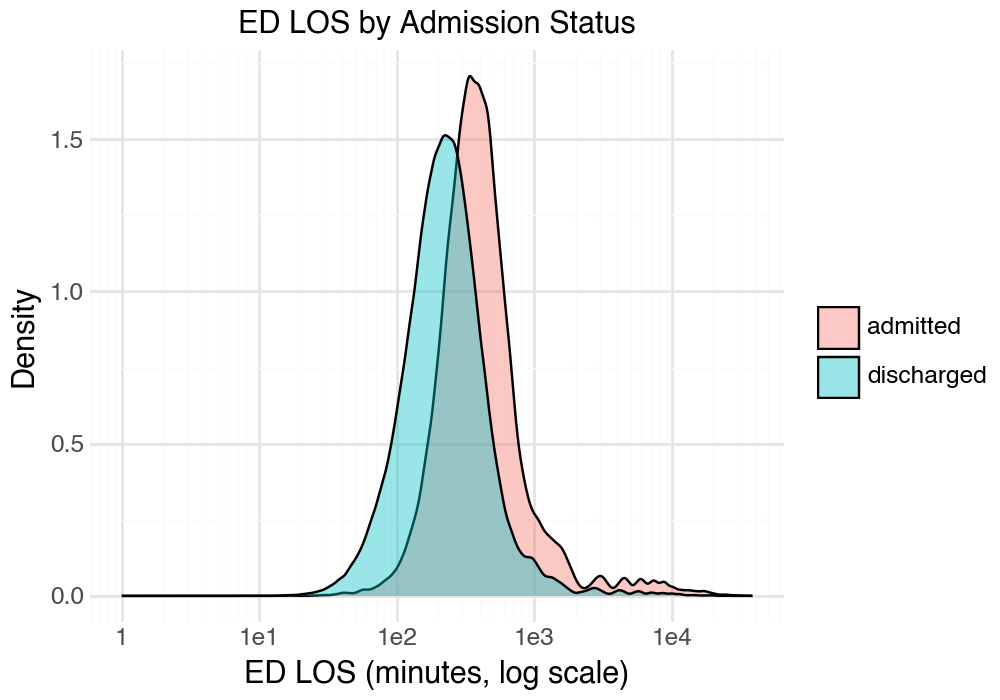

In [94]:
#Load this.
%matplotlib inline
visit_timeline = pd.read_csv(save_filepath+'visit-timeline.csv', index_col=0)

from plotnine import (
    ggplot, aes, geom_density, scale_x_log10,
    labs, theme, theme_minimal, element_text
)

plot_df = visit_timeline.copy()
plot_df['admission_status'] = plot_df['is_admitted'].map({1: 'admitted', 0: 'discharged'})
plot_df['urgency_status'] = plot_df['urgent'].map({1: 'urgent', 0: 'non-urgent'})

def los_density_plot(df, fill_col, title):
    return (
        ggplot(df, aes(x='ed_los', fill=fill_col))
        + geom_density(alpha=0.4)
        + scale_x_log10()
        + labs(title=title, x='ED LOS (minutes, log scale)', y='Density', fill='')
        + theme_minimal()
        + theme(figure_size=(5, 3.5), plot_title=element_text(size=11))
    )

#Plot by admission status.
los_density_plot(plot_df, 'admission_status', 'ED LOS by Admission Status')


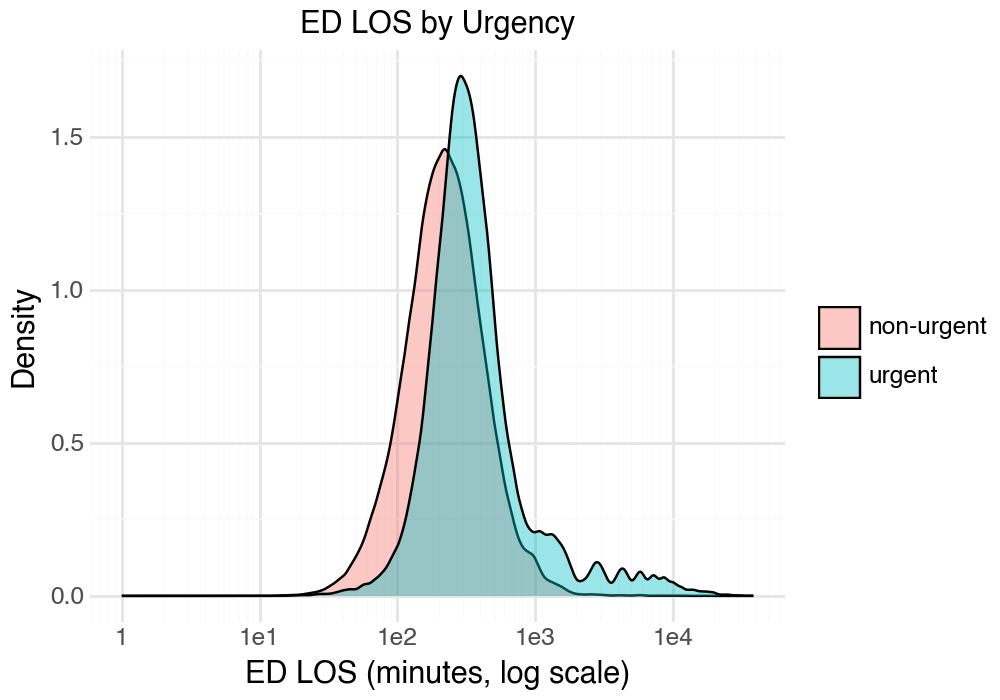

In [95]:
#Plot by urgency.
los_density_plot(plot_df, 'urgency_status', 'ED LOS by Urgency')



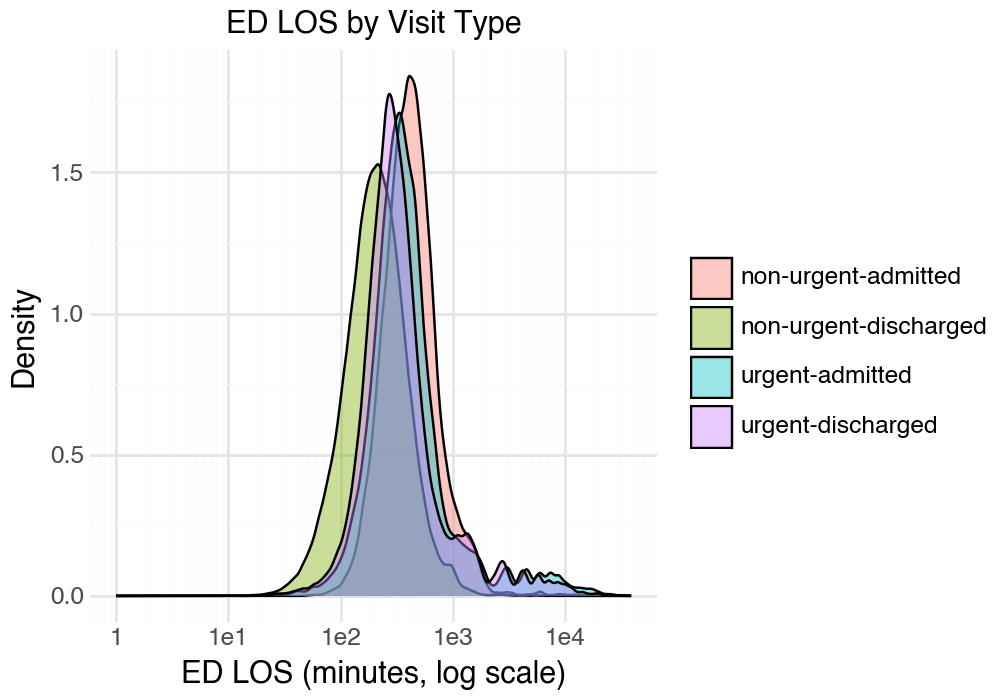

In [96]:
#Plot by visit type.
los_density_plot(plot_df, 'visit_type', 'ED LOS by Visit Type')

Now fit a lognormal distribution to each of these, where a person's wait time depends on their own state and the number of people in every other state.

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV] END colsample_bytree=0.8543759773368536, learning_rate=0.24307772206843534, max_depth=8, min_child_weight=8, n_estimators=130, reg_alpha=0.2033708730997611, reg_lambda=0.9720326832691788, subsample=0.6296164427825944; total time=   4.7s
[CV] END colsample_bytree=0.8543759773368536, learning_rate=0.24307772206843534, max_depth=8, min_child_weight=8, n_estimators=130, reg_alpha=0.2033708730997611, reg_lambda=0.9720326832691788, subsample=0.6296164427825944; total time=   4.9s
[CV] END colsample_bytree=0.8543759773368536, learning_rate=0.24307772206843534, max_depth=8, min_child_weight=8, n_estimators=130, reg_alpha=0.2033708730997611, reg_lambda=0.9720326832691788, subsample=0.6296164427825944; total time=   4.8s
[CV] END colsample_bytree=0.8543759773368536, learning_rate=0.24307772206843534, max_depth=8, min_child_weight=8, n_estimators=130, reg_alpha=0.2033708730997611, reg_lambda=0.9720326832691788, subsample=0.629616

/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.


[CV] END colsample_bytree=0.7773844571692854, learning_rate=0.10232722955740496, max_depth=3, min_child_weight=5, n_estimators=691, reg_alpha=0.08263457285474496, reg_lambda=0.11645893438488475, subsample=0.8207094176239864; total time=  12.6s
[CV] END colsample_bytree=0.7773844571692854, learning_rate=0.10232722955740496, max_depth=3, min_child_weight=5, n_estimators=691, reg_alpha=0.08263457285474496, reg_lambda=0.11645893438488475, subsample=0.8207094176239864; total time=  12.6s
[CV] END colsample_bytree=0.7773844571692854, learning_rate=0.10232722955740496, max_depth=3, min_child_weight=5, n_estimators=691, reg_alpha=0.08263457285474496, reg_lambda=0.11645893438488475, subsample=0.8207094176239864; total time=  12.3s
[CV] END colsample_bytree=0.6800680384544358, learning_rate=0.1901349456362905, max_depth=4, min_child_weight=6, n_estimators=582, reg_alpha=0.3025557837464631, reg_lambda=0.4919020237558378, subsample=0.603684598087685; total time=  12.3s
[CV] END colsample_bytree=0.

/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.


[CV] END max_depth=20, max_features=0.8583571040004383, min_samples_leaf=1, min_samples_split=13, n_estimators=289; total time= 6.7min
[CV] END max_depth=23, max_features=0.40154648334877946, min_samples_leaf=1, min_samples_split=9, n_estimators=124; total time= 1.5min
[CV] END max_depth=20, max_features=0.8583571040004383, min_samples_leaf=1, min_samples_split=13, n_estimators=289; total time= 6.3min
[CV] END max_depth=20, max_features=0.8583571040004383, min_samples_leaf=1, min_samples_split=13, n_estimators=289; total time= 6.4min
[CV] END max_depth=20, max_features=0.8583571040004383, min_samples_leaf=1, min_samples_split=13, n_estimators=289; total time= 6.4min
[CV] END max_depth=20, max_features=0.8583571040004383, min_samples_leaf=1, min_samples_split=13, n_estimators=289; total time= 6.4min
[CV] END max_depth=23, max_features=0.40154648334877946, min_samples_leaf=1, min_samples_split=9, n_estimators=124; total time= 1.2min
[CV] END max_depth=23, max_features=0.40154648334877946

/var/folders/f0/gwbmx5k5669ffg3gh0_5_k400000gn/T/ipykernel_84117/1550873704.py:209: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


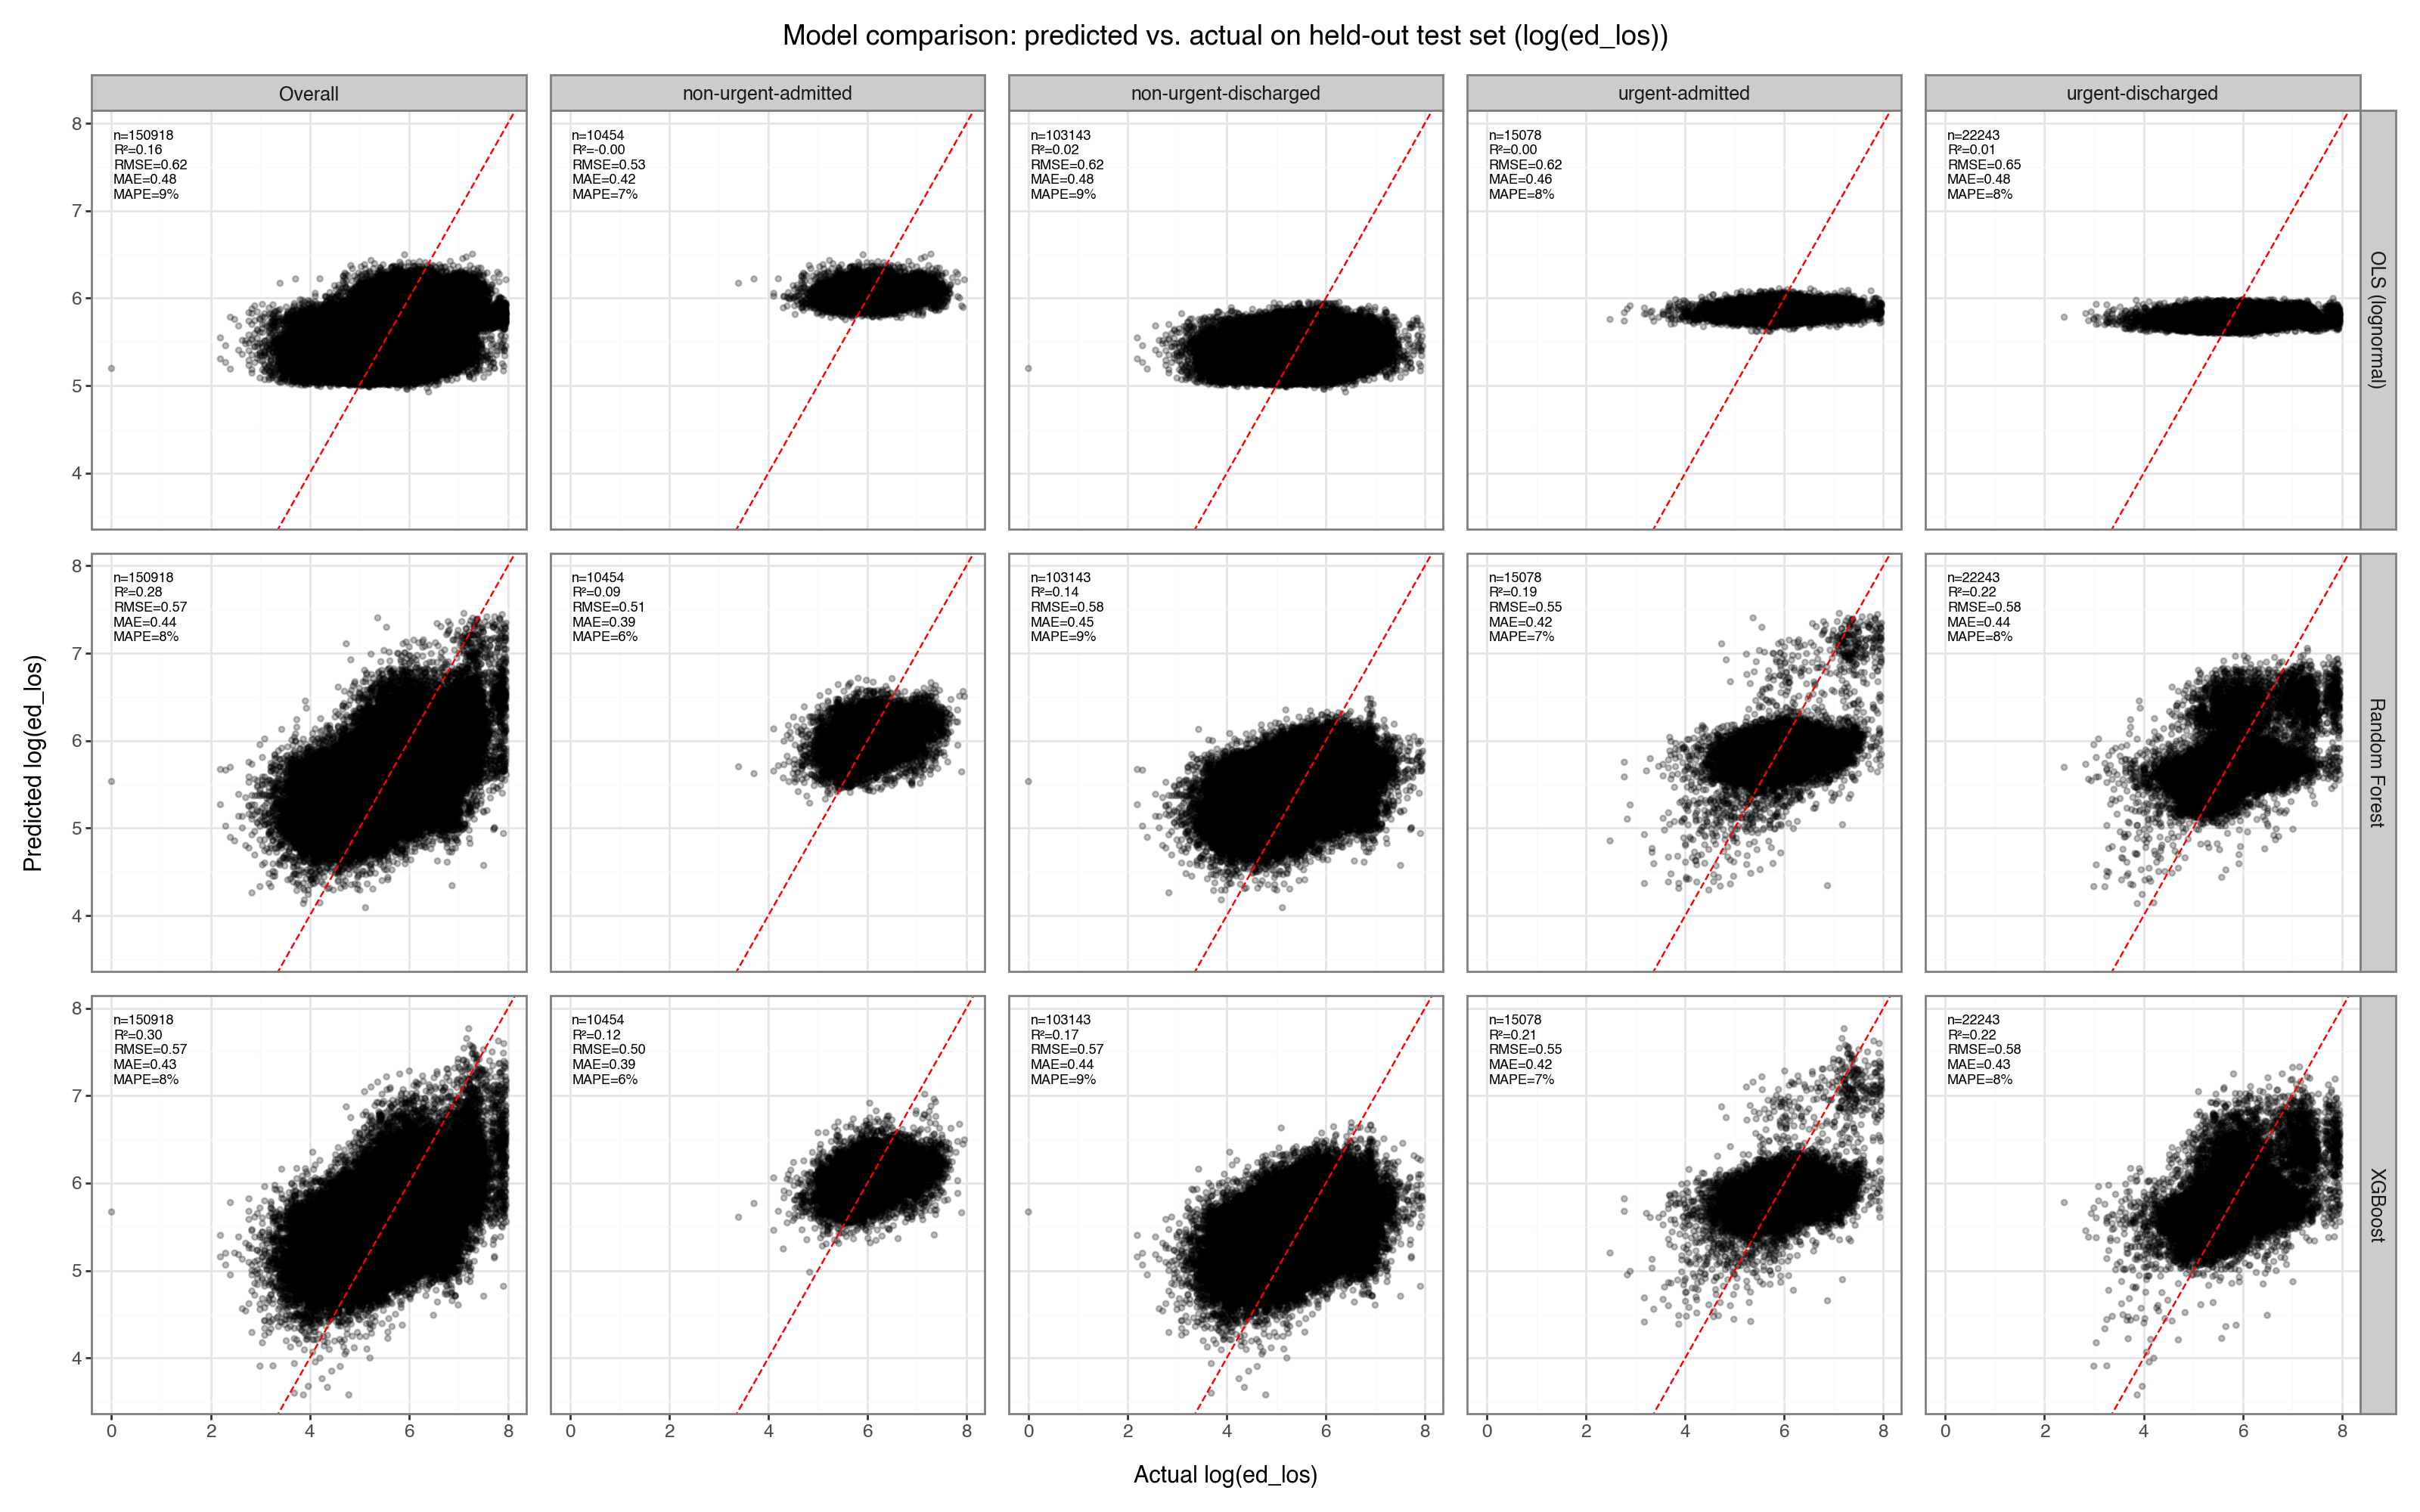

/var/folders/f0/gwbmx5k5669ffg3gh0_5_k400000gn/T/ipykernel_84117/1550873704.py:209: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


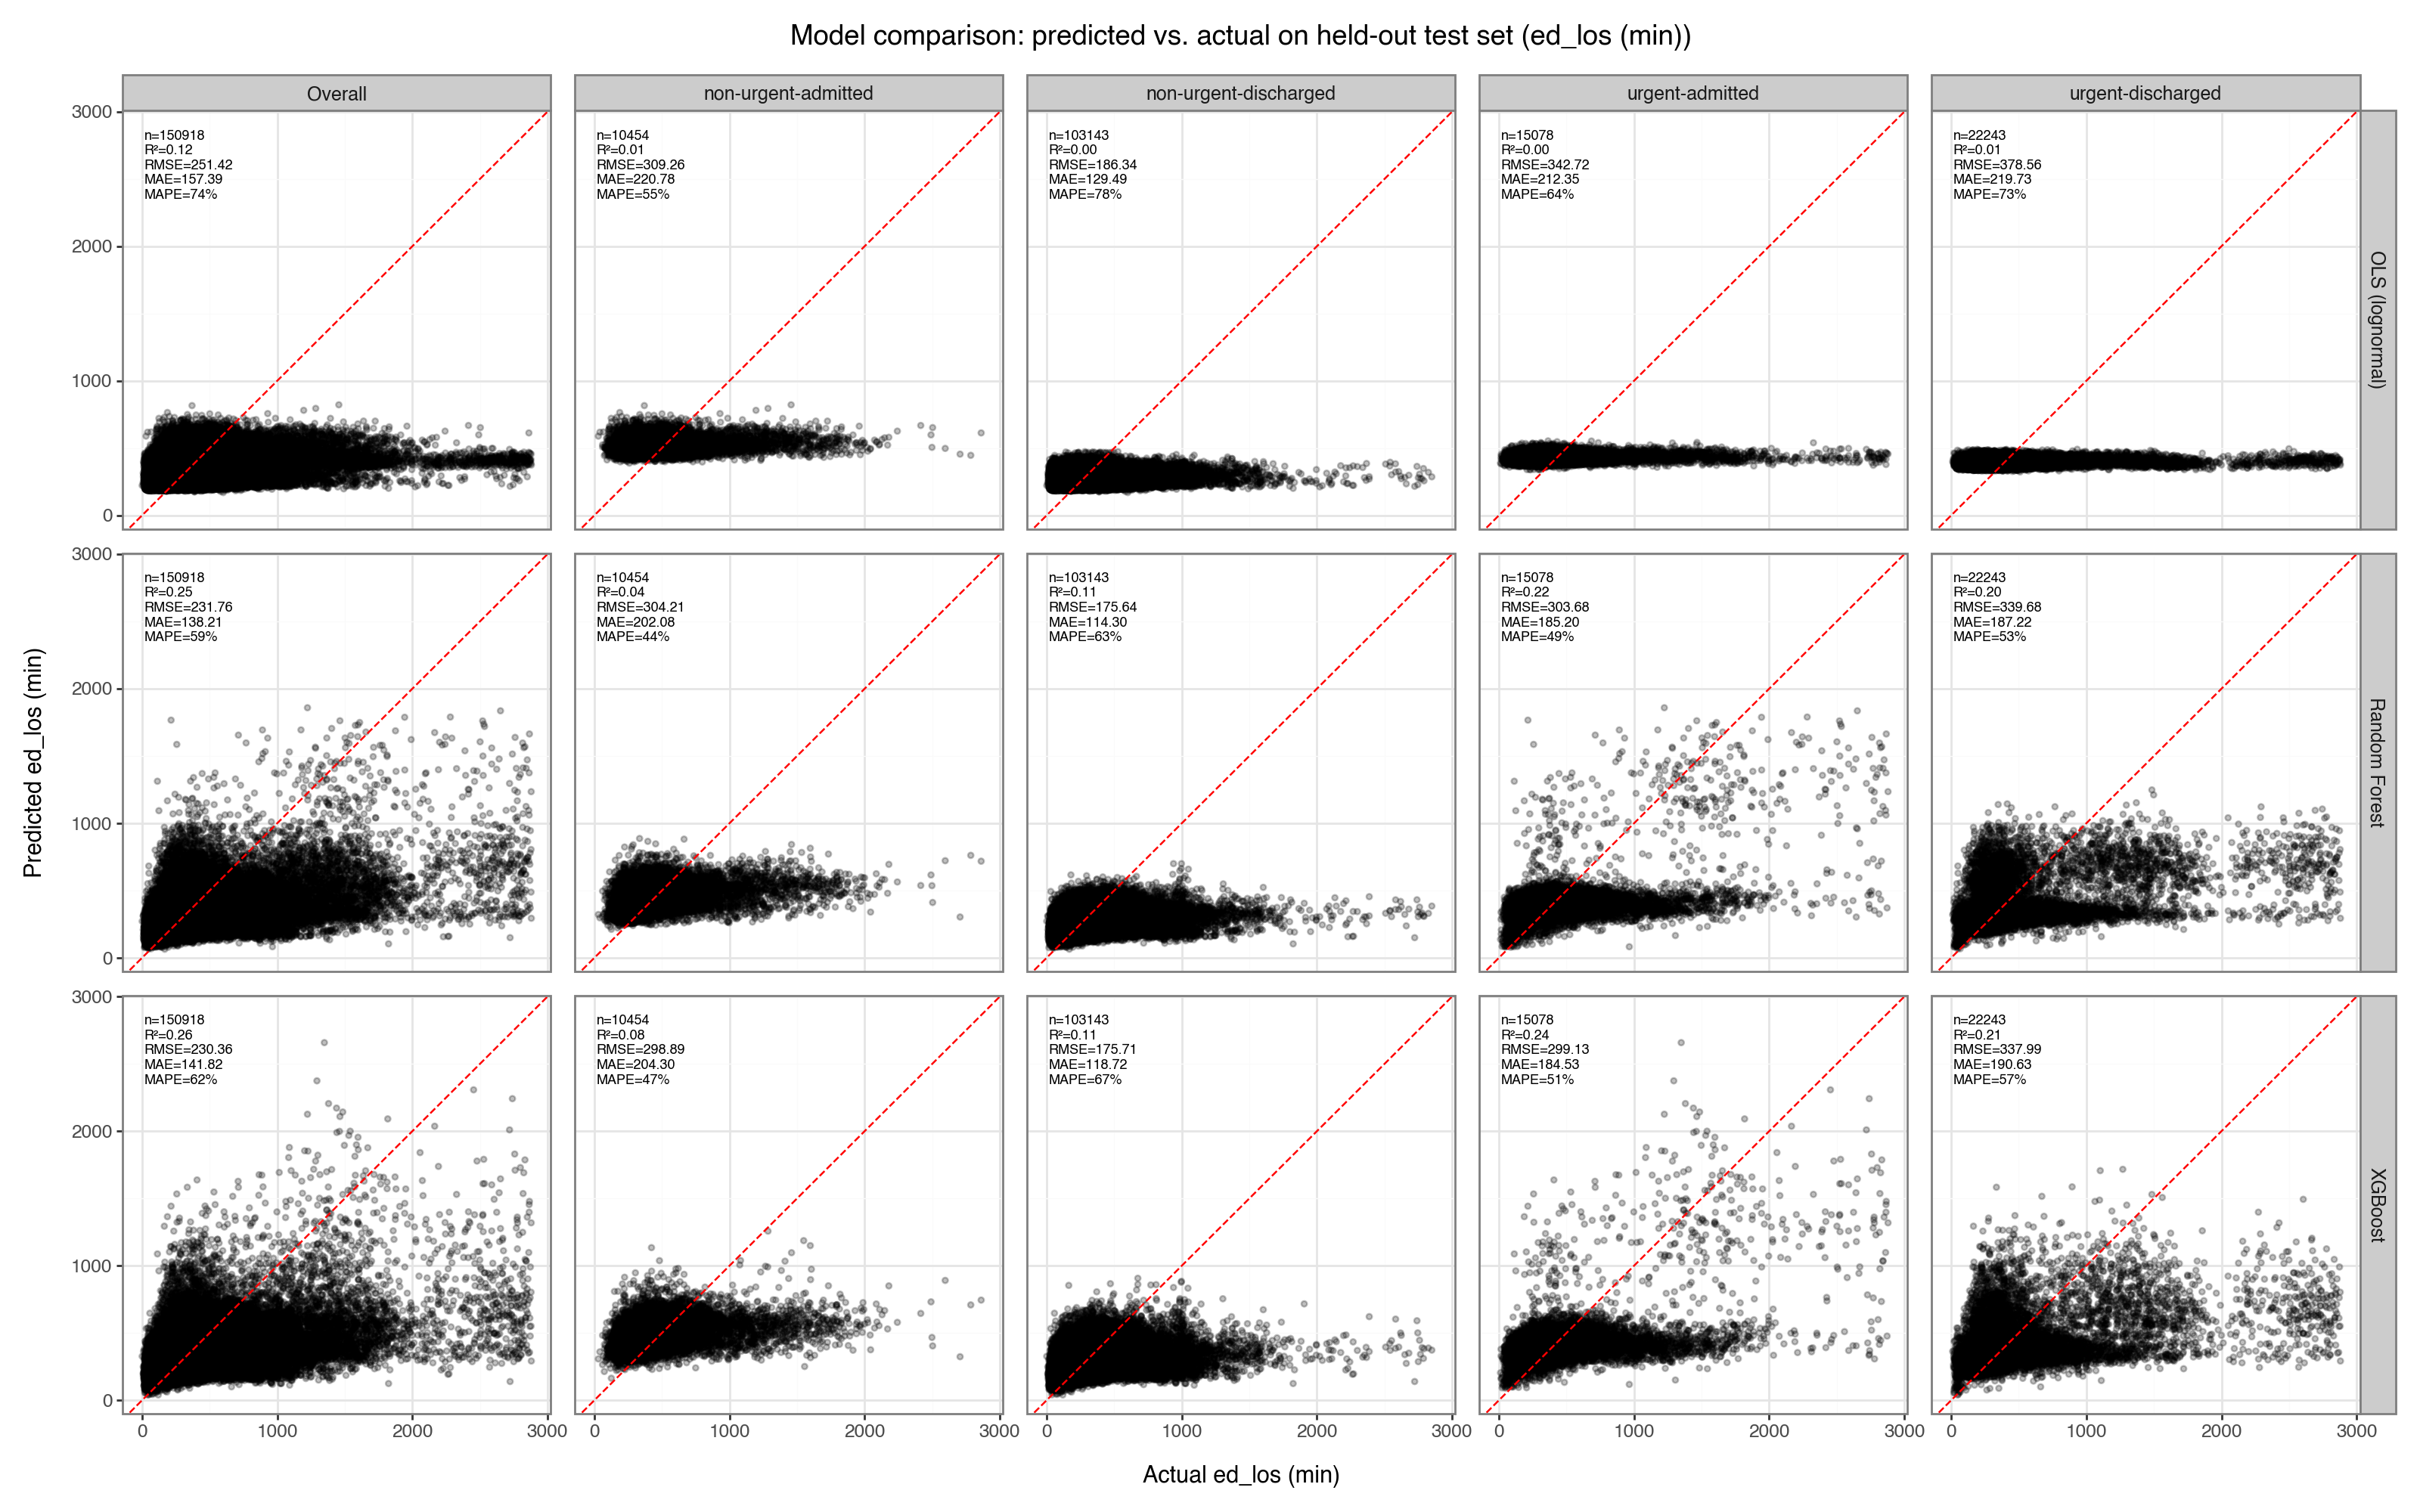

In [102]:
%matplotlib inline
import pandas as pd
import numpy as np
from scipy.stats import randint, uniform
from plotnine import (
    ggplot, aes, geom_point, geom_abline, geom_text,
    facet_grid, labs, theme_bw, theme, element_text
)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import statsmodels.formula.api as smf
import joblib

RANDOM_STATE = 210226
N_ITER_SEARCH = 100  # number of randomly sampled hyperparameter combos per model

# ----------------------------------------------------------------------
# Load & prep data
# ----------------------------------------------------------------------
visit_timeline = pd.read_csv(save_filepath + 'visit-timeline.csv', index_col=0)

raw_visits = pd.read_csv(load_filepath + raw_file_name + ".csv", index_col=0, low_memory=False)

# Truncate LOS at 48 hours (1.1% of visits are longer than this)
visit_timeline = visit_timeline[visit_timeline['ed_los'] <= 48 * 60].copy()
visit_timeline['log_ed_los'] = np.log(visit_timeline['ed_los'])

FEATURE_COLS = (['visit_type', 'non-urgent-discharged', 'urgent-admitted', 'urgent-discharged', 'non-urgent-admitted', 'is_admitted'] +
                    pre_binarised_predictors + categorical_predictors + continuous_predictors)

df = visit_timeline[['csn', 'visit_type', 'non-urgent-discharged', 'urgent-admitted', 'urgent-discharged', 'non-urgent-admitted', 'ed_los', 'log_ed_los', 'arrival']].merge(
    raw_visits[['csn', 'is_admitted'] + pre_binarised_predictors + categorical_predictors + continuous_predictors], on='csn', how='inner')

# Single train/test split shared across all models, for a fair comparison (chronological as before)
[X_train, X_test, y_train, y_test, csn_train, csn_test] = joblib.load(save_filepath+"outputs/split.joblib")
max_timestamp = df.merge(csn_train, on='csn', how='inner')['arrival'].max()
train_df, test_df = df[df['arrival'] <= max_timestamp].copy(), df[df['arrival'] > max_timestamp].copy()

train_df.to_csv(save_filepath+'intermediate-files/ed-los-train-df.csv')
test_df.to_csv(save_filepath+'intermediate-files/ed-los-test-df.csv')

# One-hot encoded feature matrices for the sklearn-style models
X_train = pd.get_dummies(train_df[FEATURE_COLS], columns=['visit_type'] + categorical_predictors, drop_first=False)
X_test = pd.get_dummies(test_df[FEATURE_COLS], columns=['visit_type'] + categorical_predictors, drop_first=False)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)  # guard against unseen categories

y_train = train_df['log_ed_los']
y_test = test_df['log_ed_los']

# CV splitter shared by both randomized searches, for a fair comparison of
# search results across model families
cv_splitter = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ----------------------------------------------------------------------
# Duan's smearing estimator: model-agnostic bias correction for
# exponentiating predictions of a log-transformed target.
# smearing factor = mean(exp(training residuals)); computed once per model
# using TRAINING residuals only, then applied to both train and test preds.
# ----------------------------------------------------------------------
def smearing_factor(y_true_log, y_pred_log):
    resid = y_true_log - y_pred_log
    return np.mean(np.exp(resid))

# ----------------------------------------------------------------------
# Fit each model on the SAME train split, predict on train + test
# ----------------------------------------------------------------------
preds = {}       # preds[model_name] = {'train': (log_pred, orig_pred), 'test': (...)}
best_params = {} # best_params[model_name] = dict of tuned hyperparameters

# --- Model 1: OLS lognormal (with visit_type interactions) ---
formula = "log_ed_los ~ visit_type * (Q('non-urgent-discharged') + Q('urgent-admitted') + Q('urgent-discharged') + Q('non-urgent-admitted'))"
ols_results = smf.ols(formula, data=train_df).fit()

ols_train_log = ols_results.predict(train_df)
ols_test_log = ols_results.predict(test_df)
smear = smearing_factor(y_train, ols_train_log)
preds['OLS (lognormal)'] = {
    'train': (ols_train_log, np.exp(ols_train_log) * smear),
    'test': (ols_test_log, np.exp(ols_test_log) * smear),
}

# --- Model 2: XGBoost, tuned via randomized search over 100 draws ---
xgb_param_dist = {
    'n_estimators': randint(100, 800),
    'max_depth': randint(2, 10),
    'learning_rate': uniform(0.01, 0.29),       # 0.01 - 0.30
    'subsample': uniform(0.5, 0.5),             # 0.5 - 1.0
    'colsample_bytree': uniform(0.5, 0.5),      # 0.5 - 1.0
    'min_child_weight': randint(1, 10),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0, 2),
}

xgb_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=xgb_param_dist,
    n_iter=N_ITER_SEARCH,
    scoring='neg_mean_squared_error',
    cv=cv_splitter,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
    verbose=2,
)
xgb_search.fit(X_train, y_train)
xgb_model = xgb_search.best_estimator_
best_params['XGBoost'] = xgb_search.best_params_

xgb_train_log = xgb_model.predict(X_train)
xgb_test_log = xgb_model.predict(X_test)
smear = smearing_factor(y_train, xgb_train_log)
preds['XGBoost'] = {
    'train': (xgb_train_log, np.exp(xgb_train_log) * smear),
    'test': (xgb_test_log, np.exp(xgb_test_log) * smear),
}

# --- Model 3: Random Forest, tuned via randomized search over 100 draws ---
rf_param_dist = {
    'n_estimators': randint(100, 800),
    'max_depth': randint(3, 30),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': uniform(0.3, 0.7),          # 0.3 - 1.0
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=int(N_ITER_SEARCH/10), #quicker for RF,
    scoring='neg_mean_squared_error',
    cv=cv_splitter,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
    verbose=2,
)
rf_search.fit(X_train, y_train)
rf_model = rf_search.best_estimator_
best_params['Random Forest'] = rf_search.best_params_

rf_train_log = rf_model.predict(X_train)
rf_test_log = rf_model.predict(X_test)
smear = smearing_factor(y_train, rf_train_log)
preds['Random Forest'] = {
    'train': (rf_train_log, np.exp(rf_train_log) * smear),
    'test': (rf_test_log, np.exp(rf_test_log) * smear),
}

# Save the winning hyperparameters + fitted models so the search doesn't
# need to be re-run every time this script is executed
joblib.dump(best_params, save_filepath + "outputs/tuned_hyperparameters.joblib")
joblib.dump(xgb_model, save_filepath + "outputs/xgb_model_tuned.joblib")
joblib.dump(rf_model, save_filepath + "outputs/rf_model_tuned.joblib")

print("Best XGBoost params:", best_params['XGBoost'])
print("Best Random Forest params:", best_params['Random Forest'])

# ----------------------------------------------------------------------
# Metrics
# ----------------------------------------------------------------------
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    nonzero = y_true != 0
    mape = np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

    return pd.Series({'n': mask.sum(), 'R2': r2, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape})

# ----------------------------------------------------------------------
# Build a long comparison dataframe (test set only — this is the honest
# out-of-sample comparison) with an added "Overall" pseudo-group
# ----------------------------------------------------------------------
def build_comparison_df(scale='log'):
    rows = []
    for model_name, p in preds.items():
        log_pred, orig_pred = p['test']
        chunk = pd.DataFrame({
            'visit_type': test_df['visit_type'].values,
            'actual_log': y_test.values,
            'pred_log': log_pred,
            'actual_orig': test_df['ed_los'].values,
            'pred_orig': orig_pred,
        })
        chunk['model'] = model_name
        rows.append(chunk)
    long_df = pd.concat(rows, ignore_index=True)

    overall = long_df.copy()
    overall['visit_type'] = 'Overall'
    long_df = pd.concat([long_df, overall], ignore_index=True)

    actual_col, pred_col = ('actual_log', 'pred_log') if scale == 'log' else ('actual_orig', 'pred_orig')
    long_df = long_df.rename(columns={actual_col: 'actual', pred_col: 'pred'})
    return long_df[['model', 'visit_type', 'actual', 'pred']]

def plot_model_comparison(scale='log', scale_label=''):
    plot_df = build_comparison_df(scale=scale)

    metrics_df = (
        plot_df.groupby(['model', 'visit_type'])
        .apply(lambda g: compute_metrics(g['actual'], g['pred']))
        .reset_index()
    )

    lo = min(plot_df['actual'].min(), plot_df['pred'].min())
    hi = max(plot_df['actual'].max(), plot_df['pred'].max())
    pad = (hi - lo) * 0.05
    lo, hi = lo - pad, hi + pad

    metrics_df['label'] = metrics_df.apply(
        lambda r: (f"n={int(r['n'])}\nR²={r['R2']:.2f}\nRMSE={r['RMSE']:.2f}\n"
                    f"MAE={r['MAE']:.2f}\nMAPE={r['MAPE']:.0f}%"),
        axis=1
    )
    metrics_df['x'] = lo + (hi - lo) * 0.05
    metrics_df['y'] = hi - (hi - lo) * 0.05

    p = (
        ggplot(plot_df, aes(x='actual', y='pred'))
        + geom_point(alpha=0.25, size=1)
        + geom_abline(slope=1, intercept=0, color='red', linetype='dashed')
        + geom_text(
            data=metrics_df,
            mapping=aes(x='x', y='y', label='label'),
            ha='left', va='top', size=6.5, color='black'
        )
        + facet_grid('model ~ visit_type')
        + labs(
            x=f'Actual {scale_label}',
            y=f'Predicted {scale_label}',
            title=f'Model comparison: predicted vs. actual on held-out test set ({scale_label})'
        )
        + theme_bw()
        + theme(figure_size=(16, 10), strip_text=element_text(size=9))
    )
    return p

# --- Log scale ---
p_log = plot_model_comparison(scale='log', scale_label='log(ed_los)')
p_log.show()

# --- Original scale ---
p_orig = plot_model_comparison(scale='orig', scale_label='ed_los (min)')
p_orig.show()

Now try more explicit survival models.

OK, this also probably isn't good enough. RNNs it is, I suppose.


Have vibe-coded an LSTM:

In [107]:
"""
LSTM for ED Length-of-Stay prediction, modeled as a causal sequence of visits
ordered by arrival time (captures crowding/queue dynamics via hidden state).

Now includes an Optuna study that tunes architecture/optimization
hyperparameters (hidden_dim, lstm_layers, dropout, lr, weight_decay,
batch_size, window_len) against validation loss, with median pruning to
kill off clearly-bad trials early. Data preprocessing (encoders, scaler,
feature engineering) is done ONCE up front and shared across all trials -
only the dataset windowing, model, and optimizer are rebuilt per trial -
so tuning doesn't redo the expensive train-only-fit steps 1e.g. 50 times.

Assumptions baked into this script (adjust to your data):
  - One dataframe per site, already sorted (or sortable) by arrival time.
    If you have multiple sites, run this pipeline separately per site, or
    add a site_id categorical feature AND reset hidden state at site boundaries.
  - timestamp_col is a NUMERIC "minutes since first arrival" index, not a
    datetime. If you also know the real calendar datetime of the first
    arrival, set Config.reference_start_datetime to reconstruct hour-of-day /
    day-of-week cyclical features; otherwise those are skipped automatically.
  - Target: LOS in minutes -> log1p-transformed for training (MSE loss on
    the log scale, back-transformed via expm1 for reporting).
  - Retrospective setting: fine to use disposition/admission status as a
    feature, since prediction is made after discharge, not at triage.
  - categorical_predictors are TEXT/STRING categories and need explicit
    integer encoding (fit on train_df only, with an "unseen" fallback bucket
    for categories that only appear in test_df).
  - pre_binarised_predictors and is_admitted are already 0/1 binary flags -
    these are treated as NUMERIC inputs, not embedded. Embedding a 2-state
    variable adds parameters for no benefit; a raw 0/1 (or its z-score)
    already represents it fully.
  - Truncated BPTT: sequences are chunked into windows; the LSTM hidden
    state is carried across consecutive windows of the same sequence and
    detached between windows to cap the backprop graph size.

Fill in continuous_predictors / categorical_predictors / pre_binarised_predictors
and the file paths in the RUN section at the bottom, then execute.

Requires: pip install optuna
"""

import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import optuna
from optuna.pruners import MedianPruner


# --------------------------------------------------------------------------
# Age banding for age-specific vital-sign normalization.
#
# Pediatric vitals (HR, RR, BP, etc.) have very different normal ranges by
# age - a heart rate that's normal for a 2-month-old is a tachycardia for a
# 10-year-old. Z-scoring across the whole population would wash that out, so
# age-dependent columns get their mean/std/median computed WITHIN each band
# instead of globally. Bin edges are in days for exact, unambiguous cutoffs.
# --------------------------------------------------------------------------
DAYS_PER_MONTH = 30.4375   # 365.25 / 12, for unambiguous month cutoffs
DAYS_PER_YEAR = 365.25

AGE_BIN_EDGES_DAYS = [
    0,
    3 * DAYS_PER_MONTH,
    6 * DAYS_PER_MONTH,
    12 * DAYS_PER_MONTH,
    18 * DAYS_PER_MONTH,
    36 * DAYS_PER_MONTH,
    5 * DAYS_PER_YEAR,
    10 * DAYS_PER_YEAR,
    15 * DAYS_PER_YEAR,
    np.inf,
]
AGE_BIN_LABELS = [
    "0-3mo", "3-6mo", "6-12mo", "12-18mo", "18-36mo",
    "3-5y", "5-10y", "10-15y", "15+",
]
UNKNOWN_AGE_GROUP = "unknown"  # fallback bucket for missing/out-of-range ages


def assign_age_group(df: pd.DataFrame, age_col: str, age_group_col: str = "age_group") -> pd.DataFrame:
    """
    Adds an age_group categorical column from a numeric age_in_days column.
    Bins are left-inclusive/right-exclusive (e.g. "0-3mo" = [0, 3mo)).
    Missing or negative/invalid ages fall back to a shared "unknown" bucket
    rather than becoming NaN, so every row still has a usable group.
    """
    df = df.copy()
    age_days = df[age_col]
    group = pd.cut(age_days, bins=AGE_BIN_EDGES_DAYS, labels=AGE_BIN_LABELS,
                    right=False, include_lowest=True)
    df[age_group_col] = group.astype(object)
    df[age_group_col] = df[age_group_col].where(age_days.notna() & (age_days >= 0), UNKNOWN_AGE_GROUP)
    df[age_group_col] = df[age_group_col].fillna(UNKNOWN_AGE_GROUP)
    return df


# --------------------------------------------------------------------------
# CONFIG - built dynamically from your predictor lists once train_df is loaded.
# Call build_config(train_df, continuous_predictors, categorical_predictors,
# pre_binarised_predictors) rather than editing a hardcoded class - see RUN
# section at the bottom.
# --------------------------------------------------------------------------
class Config:
    timestamp_col = "arrival"
    los_col = "ed_los"

    # If you know the real-world calendar datetime of the very first arrival,
    # set it here (e.g. pd.Timestamp("2021-01-04 07:12:00")) and hour-of-day /
    # day-of-week cyclical features will be reconstructed automatically.
    # Leave as None to skip those features (inter-arrival gap is still used).
    reference_start_datetime = None

    # These are populated by build_config(); placeholders here just document
    # the shape expected.
    numeric_cols = []          # continuous predictors + binary flags + is_admitted
    categorical_cols = {}      # {col: cardinality including the +1 unknown bucket}
    embedding_dims = {}        # {col: chosen embedding size, < cardinality}
    time_cols = []             # populated at feature-engineering time

    # Age-specific normalization/imputation
    age_col = "age_in_days"
    age_group_col = "age_group"
    age_dependent_cols = set()   # subset of numeric_cols normalized PER age band
    min_age_group_size = 10      # bands with fewer valid train rows fall back to global stats

    # --- Model / training hyperparameters. Defaults below are used when NOT
    # running the Optuna search (e.g. if you just want to train once); the
    # search overwrites a copy of these per-trial and the winning values are
    # copied back in before the final full training run. ---
    hidden_dim = 128
    lstm_layers = 2
    dropout = 0.1

    window_len = 100      # visits per truncated-BPTT window
    window_stride = 100   # non-overlapping; reduce for overlap
    batch_size = 16

    lr = 1e-3
    weight_decay = 0.0
    epochs = 20
    device = "cuda" if torch.cuda.is_available() else "cpu"


def build_config(train_df, continuous_predictors, categorical_predictors,
                  pre_binarised_predictors, is_admitted_col="is_admitted",
                  timestamp_col="arrival", los_col="ed_los",
                  reference_start_datetime=None,
                  age_dependent_predictors=None, age_col="age_in_days",
                  min_age_group_size=10):
    """
    Constructs a Config instance from your predictor lists.

    - continuous_predictors, pre_binarised_predictors, and is_admitted are all
      routed to numeric_cols (binary flags need no embedding).
    - categorical_predictors are TEXT columns -> get integer-encoded (see
      fit_categorical_encoders) and go through embeddings, sized well below
      their cardinality rather than equal to it.
    - age_dependent_predictors: subset of continuous_predictors (typically
      vitals like hr/sbp/dbp/rr/spo2/temp) that should be normalized and
      imputed PER age band (see AGE_BIN_LABELS) rather than globally. Must
      already be part of continuous_predictors - pass age_in_days itself
      separately if you also want raw age as a model feature.
    """
    cfg = Config()
    cfg.timestamp_col = timestamp_col
    cfg.los_col = los_col
    cfg.reference_start_datetime = reference_start_datetime

    cfg.numeric_cols = list(continuous_predictors) + list(pre_binarised_predictors) + [is_admitted_col]

    cfg.age_col = age_col
    cfg.min_age_group_size = min_age_group_size
    cfg.age_dependent_cols = set(age_dependent_predictors or [])
    unknown_age_dependent = cfg.age_dependent_cols - set(cfg.numeric_cols)
    if unknown_age_dependent:
        raise ValueError(
            f"age_dependent_predictors {sorted(unknown_age_dependent)} are not in "
            f"continuous_predictors/pre_binarised_predictors - add them there first."
        )

    # Cardinality is set once encoders are fit (train-only) - see prepare_train_test.
    # Placeholder here; overwritten in prepare_train_test after encoding.
    cfg.categorical_cols = {col: train_df[col].nunique() + 1 for col in categorical_predictors}
    cfg.embedding_dims = {col: min(50, (n + 1) // 2) for col, n in cfg.categorical_cols.items()}

    return cfg


# --------------------------------------------------------------------------
# Categorical encoding: text -> integer codes, fit on train_df ONLY.
# Index 0 is reserved for "unseen/unknown" (categories only in test_df).
# --------------------------------------------------------------------------
def fit_categorical_encoders(train_df: pd.DataFrame, cat_col_names: list) -> dict:
    encoders = {}
    for col in cat_col_names:
        categories = sorted(train_df[col].dropna().astype(str).unique().tolist())
        encoders[col] = {cat: i + 1 for i, cat in enumerate(categories)}  # 0 reserved for unknown
    return encoders


def apply_categorical_encoders(df: pd.DataFrame, cat_col_names: list, encoders: dict) -> pd.DataFrame:
    df = df.copy()
    for col in cat_col_names:
        df[col] = df[col].astype(str).map(encoders[col]).fillna(0).astype(np.int64)
    return df


# --------------------------------------------------------------------------
# Feature engineering
#
# Split into fit_scaler (train_df only) + apply_features (any df), so
# normalization stats and outlier caps never leak from test into train.
# --------------------------------------------------------------------------
def add_time_and_target_features(df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    """
    Deterministic features that don't need fitting: safe to apply to any split.

    timestamp_col is a numeric minutes-since-first-arrival index (not a
    datetime). Cyclical hour-of-day / day-of-week features are only added if
    cfg.reference_start_datetime is set; otherwise cfg.time_cols stays empty
    and the model relies on inter-arrival gap alone for temporal context.
    """
    df = df.sort_values(cfg.timestamp_col).reset_index(drop=True)

    if cfg.reference_start_datetime is not None:
        real_ts = cfg.reference_start_datetime + pd.to_timedelta(df[cfg.timestamp_col], unit="m")
        hour = real_ts.dt.hour + real_ts.dt.minute / 60.0
        df["hour_sin"] = np.sin(2 * np.pi * hour / 24)
        df["hour_cos"] = np.cos(2 * np.pi * hour / 24)
        dow = real_ts.dt.dayofweek
        df["dow_sin"] = np.sin(2 * np.pi * dow / 7)
        cfg.time_cols = ["hour_sin", "hour_cos", "dow_sin"]
    else:
        cfg.time_cols = []

    # timestamp_col is already in minutes, so a simple diff gives the gap directly
    df["inter_arrival_gap"] = df[cfg.timestamp_col].diff().fillna(0)

    df["log_los"] = np.log1p(df[cfg.los_col].clip(lower=0))
    return df


def diagnose_missingness(df: pd.DataFrame, numeric_cols: list, los_col: str) -> None:
    """
    Prints NaN/Inf counts per numeric column and the target. Run this on
    train_df and test_df BEFORE training - an LSTM will silently produce
    NaN loss for the entire run if even one row has a missing/infinite value,
    since the hidden state carries the NaN forward through the whole sequence.
    """
    print("--- missingness / infinity check ---")
    any_found = False
    for col in numeric_cols + [los_col]:
        n_nan = df[col].isna().sum()
        n_inf = int(np.isinf(df[col].to_numpy(dtype=float, na_value=0.0)).sum())
        if n_nan or n_inf:
            any_found = True
            print(f"  {col}: {n_nan} NaN, {n_inf} Inf (of {len(df)} rows)")
    if not any_found:
        print("  none found")
    print("-------------------------------------")


def _fit_global_stats(series: pd.Series) -> dict:
    clean = series.replace([np.inf, -np.inf], np.nan)
    return {"mu": clean.mean(), "sigma": clean.std() + 1e-6, "median": clean.median()}


def _fit_age_specific_stats(train_df: pd.DataFrame, col: str, age_group_col: str,
                             min_group_size: int) -> dict:
    """
    Global stats (fallback) plus per-age-band stats for one column. A band
    with fewer than min_group_size valid (non-NaN, non-Inf) train rows is
    skipped and falls back to the global stats at apply time - protects
    against a near-empty band producing a degenerate mean/std.
    """
    global_stats = _fit_global_stats(train_df[col])
    clean = train_df[col].replace([np.inf, -np.inf], np.nan)
    by_group = {}
    for group, series in clean.groupby(train_df[age_group_col]):
        if series.notna().sum() < min_group_size:
            continue
        by_group[group] = {"mu": series.mean(), "sigma": series.std() + 1e-6, "median": series.median()}
    return {"age_dependent": True, "global": global_stats, "by_group": by_group}


def fit_scaler(train_df: pd.DataFrame, cfg: Config) -> dict:
    """
    Compute normalization stats, an imputation value, and the outlier cap
    from train_df ONLY. Median (not mean) is used for imputation since it's
    robust to the same skew/outliers the gap cap is protecting against.

    Columns in cfg.age_dependent_cols get PER-AGE-BAND mu/sigma/median
    (train_df must already have an age_group column - see assign_age_group,
    called in prepare_train_test before this runs). All other numeric
    columns, plus inter_arrival_gap, keep a single global set of stats.
    """
    stats = {}
    gap_cap = train_df["inter_arrival_gap"].quantile(0.99)
    stats["inter_arrival_gap_cap"] = gap_cap
    capped_gap = train_df["inter_arrival_gap"].clip(upper=gap_cap)

    for col in cfg.numeric_cols:
        if col in cfg.age_dependent_cols:
            stats[col] = _fit_age_specific_stats(train_df, col, cfg.age_group_col, cfg.min_age_group_size)
        else:
            stats[col] = {"age_dependent": False, "global": _fit_global_stats(train_df[col])}

    stats["inter_arrival_gap"] = {"age_dependent": False, "global": _fit_global_stats(capped_gap)}
    return stats


def apply_features(df: pd.DataFrame, cfg: Config, scaler: dict) -> pd.DataFrame:
    """
    Apply train-fit normalization/capping/imputation to any split.

    For each numeric column: infinities are treated as missing, missing
    values are imputed (with the TRAIN median - either global, or the
    row's own age band's median for age-dependent columns), and a
    same-named "<col>_missing" indicator flag is added so the model can
    still use the fact that a value was missing (often informative in
    clinical data) rather than just silently filling it in.

    Age-dependent columns (cfg.age_dependent_cols) look up mu/sigma/median
    from the row's own age_group; if that band had too few train rows (see
    min_age_group_size) or the row's age_group wasn't seen at all, it falls
    back to that column's global stats.

    Columns are assembled in dicts and joined once via pd.concat, instead of
    being inserted one at a time, to avoid DataFrame fragmentation.
    """
    df = df.copy()
    df["inter_arrival_gap"] = df["inter_arrival_gap"].clip(upper=scaler["inter_arrival_gap_cap"])

    new_cols = {}
    for col in cfg.numeric_cols + ["inter_arrival_gap"]:
        col_stats = scaler[col]
        raw = df[col].replace([np.inf, -np.inf], np.nan)
        is_missing = raw.isna()

        if col_stats["age_dependent"]:
            by_group = col_stats["by_group"]
            fallback = col_stats["global"]
            row_stats = df[cfg.age_group_col].map(lambda g: by_group.get(g, fallback))
            mu = row_stats.map(lambda s: s["mu"])
            sigma = row_stats.map(lambda s: s["sigma"])
            median = row_stats.map(lambda s: s["median"])
        else:
            mu, sigma, median = col_stats["global"]["mu"], col_stats["global"]["sigma"], col_stats["global"]["median"]

        imputed = raw.fillna(median)
        new_cols[col + "_z"] = (imputed - mu) / sigma

        # Skip a missing-indicator column for inter_arrival_gap - it's
        # already guaranteed non-null (first row is filled with 0 upstream).
        if col != "inter_arrival_gap":
            new_cols[col + "_missing"] = is_missing.astype(np.float32)

    df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)

    # Fail loudly here rather than silently training on NaNs for N epochs -
    # if this trips, a column exists that isn't in cfg.numeric_cols but
    # should be, or the imputation above has a gap.
    remaining_nan_cols = [c for c in new_cols if df[c].isna().any()]
    if remaining_nan_cols:
        raise ValueError(
            f"NaNs remain after imputation in columns: {remaining_nan_cols}. "
            f"Check that these columns exist and are fully numeric in both "
            f"train_df and test_df."
        )

    return df


def prepare_train_test(train_df: pd.DataFrame, test_df: pd.DataFrame, cfg: Config):
    """
    Fits categorical encoders, time features, and the numeric scaler on
    train_df only, then applies all of it identically to test_df. Also
    updates cfg.categorical_cols / cfg.embedding_dims to reflect the actual
    fit encoders (cardinality = known categories + 1 unknown bucket).

    Returns (train_df, test_df, scaler, categorical_encoders). This whole
    function is run ONCE, before hyperparameter tuning starts, since none of
    it depends on the hyperparameters being searched over.
    """
    cat_cols = list(cfg.categorical_cols.keys())

    print("Checking train_df for missing/infinite numeric values...")
    diagnose_missingness(train_df, cfg.numeric_cols, cfg.los_col)
    print("Checking test_df for missing/infinite numeric values...")
    diagnose_missingness(test_df, cfg.numeric_cols, cfg.los_col)

    categorical_encoders = fit_categorical_encoders(train_df, cat_cols)
    # Recompute cardinality/embedding sizes from the actual fit encoders,
    # in case build_config()'s earlier nunique()-based estimate was off
    # (e.g. due to NaNs, or categories that only appear once).
    cfg.categorical_cols = {col: len(mapping) + 1 for col, mapping in categorical_encoders.items()}
    cfg.embedding_dims = {col: min(50, (n + 1) // 2) for col, n in cfg.categorical_cols.items()}

    train_df = apply_categorical_encoders(train_df, cat_cols, categorical_encoders)
    test_df = apply_categorical_encoders(test_df, cat_cols, categorical_encoders)

    train_df = add_time_and_target_features(train_df, cfg)
    test_df = add_time_and_target_features(test_df, cfg)

    if cfg.age_dependent_cols:
        train_df = assign_age_group(train_df, cfg.age_col, cfg.age_group_col)
        test_df = assign_age_group(test_df, cfg.age_col, cfg.age_group_col)

    scaler = fit_scaler(train_df, cfg)
    train_df = apply_features(train_df, cfg, scaler)
    test_df = apply_features(test_df, cfg, scaler)

    # Sanity check worth watching: how often test_df falls back to "unknown"
    for col in cat_cols:
        unseen_frac = (test_df[col] == 0).mean()
        if unseen_frac > 0.05:
            print(f"[warning] '{col}': {unseen_frac:.1%} of test_df rows are "
                  f"unseen categories (mapped to the unknown bucket). Consider "
                  f"coarser category grouping if this is high.")

    return train_df, test_df, scaler, categorical_encoders


# --------------------------------------------------------------------------
# Dataset: chunked, chronological windows for truncated BPTT
# --------------------------------------------------------------------------
class VisitSequenceDataset(Dataset):
    def __init__(self, df: pd.DataFrame, cfg: Config):
        self.cfg = cfg
        self.cat_cols = list(cfg.categorical_cols.keys())
        self.num_cols = (
            [c + "_z" for c in cfg.numeric_cols]
            + [c + "_missing" for c in cfg.numeric_cols]
            + ["inter_arrival_gap_z"]
        )
        self.time_cols = cfg.time_cols  # [] if reference_start_datetime wasn't set

        self.cats = df[self.cat_cols].values.astype(np.int64) if self.cat_cols else np.zeros((len(df), 0), dtype=np.int64)
        self.nums = df[self.num_cols + self.time_cols].values.astype(np.float32)
        self.targets = df["log_los"].values.astype(np.float32)

        n = len(df)
        self.windows = [
            (start, min(start + cfg.window_len, n))
            for start in range(0, n, cfg.window_stride)
        ]

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, idx):
        start, end = self.windows[idx]
        return {
            "cats": torch.from_numpy(self.cats[start:end]),
            "nums": torch.from_numpy(self.nums[start:end]),
            "targets": torch.from_numpy(self.targets[start:end]),
        }


def collate_pad(batch):
    """Pads variable-length windows (last window in a sequence may be shorter)."""
    lengths = [b["cats"].shape[0] for b in batch]
    max_len = max(lengths)
    n_cat = batch[0]["cats"].shape[1]
    n_num = batch[0]["nums"].shape[1]

    cats = torch.zeros(len(batch), max_len, n_cat, dtype=torch.long)
    nums = torch.zeros(len(batch), max_len, n_num, dtype=torch.float32)
    targets = torch.zeros(len(batch), max_len, dtype=torch.float32)
    mask = torch.zeros(len(batch), max_len, dtype=torch.bool)

    for i, b in enumerate(batch):
        L = lengths[i]
        cats[i, :L] = b["cats"]
        nums[i, :L] = b["nums"]
        targets[i, :L] = b["targets"]
        mask[i, :L] = True

    return cats, nums, targets, mask


# --------------------------------------------------------------------------
# Model: embeddings (categorical only) + numerics -> causal LSTM -> skip -> head
# --------------------------------------------------------------------------
class LSTMLosModel(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.cat_cols = list(cfg.categorical_cols.keys())

        self.embeddings = nn.ModuleDict({
            col: nn.Embedding(cfg.categorical_cols[col], cfg.embedding_dims[col])
            for col in self.cat_cols
        })

        # numeric_cols contribute a value column AND a missing-indicator column each,
        # plus +1 for inter_arrival_gap_z, plus any time_cols
        n_num_inputs = (len(cfg.numeric_cols) * 2) + 1 + len(cfg.time_cols)
        input_dim = sum(cfg.embedding_dims.values()) + n_num_inputs

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=cfg.hidden_dim,
            num_layers=cfg.lstm_layers,
            batch_first=True,
            dropout=cfg.dropout if cfg.lstm_layers > 1 else 0.0,
        )

        # Skip connection: concat raw static features with LSTM output before the head.
        # Lets strong static predictors (triage, diagnosis) bypass the recurrent
        # bottleneck instead of being forced entirely through the hidden state.
        head_in = cfg.hidden_dim + input_dim
        self.head = nn.Sequential(
            nn.Linear(head_in, cfg.hidden_dim),
            nn.ReLU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, 1),
        )

    def build_input(self, cats, nums):
        if self.cat_cols:
            emb = [self.embeddings[col](cats[..., i]) for i, col in enumerate(self.cat_cols)]
            x = torch.cat(emb + [nums], dim=-1)
        else:
            x = nums
        return x

    def forward(self, cats, nums, hidden=None):
        x = self.build_input(cats, nums)              # (B, T, input_dim)
        out, hidden = self.lstm(x, hidden)             # out: (B, T, hidden_dim)
        combined = torch.cat([out, x], dim=-1)         # skip connection
        pred = self.head(combined).squeeze(-1)         # (B, T) - predicted log_los
        return pred, hidden


# --------------------------------------------------------------------------
# Training loop with stateful hidden-state carrying across consecutive windows
# --------------------------------------------------------------------------
def train_one_epoch(model, loader, cfg, optimizer):
    model.train()
    hidden = None
    total_loss, n_seen = 0.0, 0

    for cats, nums, targets, mask in loader:
        cats, nums, targets, mask = (
            cats.to(cfg.device), nums.to(cfg.device),
            targets.to(cfg.device), mask.to(cfg.device),
        )

        # Detach hidden state so gradients don't flow through the whole history
        # (this is what makes it "truncated" BPTT). If batch size changes on the
        # last batch, just reset hidden to None instead of carrying it.
        if hidden is not None and hidden[0].shape[1] == cats.shape[0]:
            hidden = tuple(h.detach() for h in hidden)
        else:
            hidden = None

        optimizer.zero_grad()
        pred, hidden = model(cats, nums, hidden)

        loss = ((pred - targets) ** 2 * mask).sum() / mask.sum().clamp(min=1)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * mask.sum().item()
        n_seen += mask.sum().item()

    return total_loss / max(n_seen, 1)


@torch.no_grad()
def evaluate(model, loader, cfg):
    model.eval()
    hidden = None
    all_pred, all_true = [], []

    for cats, nums, targets, mask in loader:
        cats, nums, targets, mask = (
            cats.to(cfg.device), nums.to(cfg.device),
            targets.to(cfg.device), mask.to(cfg.device),
        )
        if hidden is not None and hidden[0].shape[1] == cats.shape[0]:
            hidden = tuple(h.detach() for h in hidden)
        else:
            hidden = None

        pred, hidden = model(cats, nums, hidden)
        all_pred.append(pred[mask].cpu().numpy())
        all_true.append(targets[mask].cpu().numpy())

    pred = np.concatenate(all_pred)
    true = np.concatenate(all_true)

    # Back-transform to original LOS units for interpretable metrics
    pred_los = np.expm1(pred)
    true_los = np.expm1(true)
    mae = np.mean(np.abs(pred_los - true_los))
    rmse = np.sqrt(np.mean((pred_los - true_los) ** 2))
    return {"log_mse": np.mean((pred - true) ** 2), "mae_original_units": mae, "rmse_original_units": rmse}


def build_loaders(fit_df, val_df, test_df, cfg):
    """(Re)builds windowed datasets/loaders for a given cfg. Cheap - no
    feature engineering happens here, just windowing + tensor conversion -
    so it's fine to call this fresh for every Optuna trial."""
    train_ds = VisitSequenceDataset(fit_df, cfg)
    val_ds = VisitSequenceDataset(val_df, cfg)
    test_ds = VisitSequenceDataset(test_df, cfg) if test_df is not None else None

    # shuffle=False is required: window order within a sequence must stay
    # chronological for the carried hidden state to mean anything.
    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=False, collate_fn=collate_pad)
    val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, collate_fn=collate_pad)
    test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, collate_fn=collate_pad) if test_ds is not None else None
    return train_loader, val_loader, test_loader


def run_training(cfg, fit_df, val_df, test_df=None, epochs=None, trial=None, verbose=True):
    """
    Builds a fresh model + loaders for cfg and trains for `epochs` (defaults
    to cfg.epochs). If `trial` is given (an optuna.Trial), reports val
    log_mse after every epoch and raises optuna.TrialPruned() if the trial
    looks unpromising relative to others - this is what lets bad
    hyperparameter draws get killed early instead of running to completion.

    Returns (model, best_val_log_mse, test_metrics_or_None).
    """
    epochs = epochs if epochs is not None else cfg.epochs
    train_loader, val_loader, test_loader = build_loaders(fit_df, val_df, test_df, cfg)

    model = LSTMLosModel(cfg).to(cfg.device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    best_val_log_mse = float("inf")
    for epoch in range(epochs):
        train_loss = train_one_epoch(model, train_loader, cfg, optimizer)
        val_metrics = evaluate(model, val_loader, cfg)
        best_val_log_mse = min(best_val_log_mse, val_metrics["log_mse"])

        if verbose:
            print(f"epoch {epoch+1:02d} | train_log_mse {train_loss:.4f} | "
                  f"val_log_mse {val_metrics['log_mse']:.4f} | "
                  f"val_mae {val_metrics['mae_original_units']:.1f} | "
                  f"val_rmse {val_metrics['rmse_original_units']:.1f}")

        if trial is not None:
            trial.report(val_metrics["log_mse"], step=epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

    test_metrics = evaluate(model, test_loader, cfg) if test_loader is not None else None
    return model, best_val_log_mse, test_metrics


# --------------------------------------------------------------------------
# Optuna: search over architecture + optimization hyperparameters.
# Data preprocessing (prepare_train_test) is done ONCE beforehand and
# fit_df/val_df are shared read-only across all trials - only the parts of
# cfg that affect the model/training loop are varied.
# --------------------------------------------------------------------------
def make_objective(base_cfg, fit_df, val_df, tuning_epochs):
    def objective(trial):
        cfg = copy.deepcopy(base_cfg)

        cfg.hidden_dim = trial.suggest_int("hidden_dim", 32, 256, log=True)
        cfg.lstm_layers = trial.suggest_int("lstm_layers", 1, 3)
        cfg.dropout = trial.suggest_float("dropout", 0.0, 0.5)
        cfg.lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
        cfg.weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
        cfg.batch_size = trial.suggest_categorical("batch_size", [8, 16, 32, 64])
        # Keep windows non-overlapping (stride == len); overlap could be
        # added as a separate tuned fraction later if useful.
        cfg.window_len = trial.suggest_int("window_len", 50, 200, step=25)
        cfg.window_stride = cfg.window_len

        _, best_val_log_mse, _ = run_training(
            cfg, fit_df, val_df, test_df=None,
            epochs=tuning_epochs, trial=trial, verbose=False,
        )
        return best_val_log_mse

    return objective


def tune_hyperparameters(base_cfg, fit_df, val_df, n_trials=50, tuning_epochs=8, seed=0):
    """
    Runs the Optuna study. tuning_epochs is deliberately smaller than the
    final full-training epoch count (cfg.epochs) - each trial only needs
    enough epochs to rank hyperparameter choices, not to fully converge -
    combined with median pruning this keeps a 50-trial search tractable.
    Returns the completed optuna.Study.
    """
    sampler = optuna.samplers.TPESampler(seed=seed)
    pruner = MedianPruner(n_startup_trials=5, n_warmup_steps=2)
    study = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner)
    study.optimize(make_objective(base_cfg, fit_df, val_df, tuning_epochs), n_trials=n_trials)

    print(f"Best trial: val_log_mse={study.best_value:.4f}")
    print("Best params:", study.best_params)
    return study


# --------------------------------------------------------------------------
# Main: takes your existing chronologically-split train_df / test_df
# --------------------------------------------------------------------------
def main(train_df_raw: pd.DataFrame, test_df_raw: pd.DataFrame, cfg: Config, val_frac: float = 0.15,
         run_tuning: bool = True, n_trials: int = 50, tuning_epochs: int = 8, final_epochs: int = None):
    """
    train_df_raw, test_df_raw: your existing splits, each still containing the
    raw columns named in cfg (timestamp, LOS, numeric, categorical text
    columns). They should already be in chronological order (or at least
    each internally sortable by cfg.timestamp_col) and non-overlapping in
    time, with test_df entirely after train_df.

    val_frac: fraction carved off the END of train_df (chronologically) for
    monitoring during training and for the Optuna objective. This does NOT
    touch test_df, so test remains a clean, only-looked-at-once final check.

    run_tuning: if True, runs an Optuna search (n_trials draws, tuning_epochs
    each) over hidden_dim/lstm_layers/dropout/lr/weight_decay/batch_size/
    window_len, then trains a final model with the winning hyperparameters
    for final_epochs (defaults to cfg.epochs). If False, just trains cfg as
    given (the old behavior).
    """
    train_df, test_df, scaler, categorical_encoders = prepare_train_test(train_df_raw, test_df_raw, cfg)

    # Carve validation off the tail of train_df, chronologically - never shuffle.
    n_train = len(train_df)
    split_point = int(n_train * (1 - val_frac))
    fit_df = train_df.iloc[:split_point]
    val_df = train_df.iloc[split_point:]

    if run_tuning:
        study = tune_hyperparameters(cfg, fit_df, val_df, n_trials=n_trials, tuning_epochs=tuning_epochs)
        final_cfg = copy.deepcopy(cfg)
        for k, v in study.best_params.items():
            setattr(final_cfg, k, v)
        final_cfg.window_stride = final_cfg.window_len
    else:
        study = None
        final_cfg = cfg

    model, best_val_log_mse, test_metrics = run_training(
        final_cfg, fit_df, val_df, test_df=test_df,
        epochs=final_epochs if final_epochs is not None else final_cfg.epochs,
        trial=None, verbose=True,
    )

    print("TEST:", test_metrics)
    return model, test_metrics, scaler, categorical_encoders, final_cfg, study


# --------------------------------------------------------------------------
# RUN 
# --------------------------------------------------------------------------

# Vitals that should be normalized/imputed PER AGE BAND rather than
# globally - must already be listed in continuous_predictors above.
age_dependent_predictors = ['raw_weight',
     'raw_triage_dbp', 'raw_triage_hr', 'raw_triage_pain', 'raw_triage_rr', 'raw_triage_sbp', 'raw_triage_sp_o2']

train_df = pd.read_csv(save_filepath + 'intermediate-files/ed-los-train-df.csv', index_col=0)
test_df = pd.read_csv(save_filepath + 'intermediate-files/ed-los-test-df.csv', index_col=0)

cfg = build_config(
    train_df,
    continuous_predictors=continuous_predictors,
    categorical_predictors=categorical_predictors,
    pre_binarised_predictors=pre_binarised_predictors,
    is_admitted_col="is_admitted",
    timestamp_col="arrival",     # numeric minutes-since-first-arrival
    los_col="ed_los",
    reference_start_datetime=None,  # set to a pd.Timestamp if you know the real start time
    age_dependent_predictors=age_dependent_predictors,
    age_col="age_in_days",
)

model, test_metrics, scaler, categorical_encoders, final_cfg, study = main(
    train_df, test_df, cfg,
    run_tuning=True,     # set False to skip Optuna and just train cfg as-is
    n_trials=50,          # number of hyperparameter draws
    tuning_epochs=5,      # short training runs used to rank hyperparameters
    final_epochs=20,      # full training length once the winner is picked
)

Checking train_df for missing/infinite numeric values...
--- missingness / infinity check ---
  miles_travelled: 2517 NaN, 0 Inf (of 151596 rows)
  sdi_score: 2538 NaN, 0 Inf (of 151596 rows)
  raw_weight: 6421 NaN, 0 Inf (of 151596 rows)
  raw_triage_dbp: 17737 NaN, 0 Inf (of 151596 rows)
  raw_triage_hr: 44593 NaN, 0 Inf (of 151596 rows)
  raw_triage_pain: 114197 NaN, 0 Inf (of 151596 rows)
  raw_triage_rr: 45147 NaN, 0 Inf (of 151596 rows)
  raw_triage_sbp: 17496 NaN, 0 Inf (of 151596 rows)
  raw_triage_sp_o2: 60197 NaN, 0 Inf (of 151596 rows)
-------------------------------------
Checking test_df for missing/infinite numeric values...
--- missingness / infinity check ---
  miles_travelled: 1879 NaN, 0 Inf (of 150918 rows)
  sdi_score: 1908 NaN, 0 Inf (of 150918 rows)
  raw_weight: 5650 NaN, 0 Inf (of 150918 rows)
  raw_triage_dbp: 41912 NaN, 0 Inf (of 150918 rows)
  raw_triage_hr: 43232 NaN, 0 Inf (of 150918 rows)
  raw_triage_pain: 119314 NaN, 0 Inf (of 150918 rows)
  raw_triage_r

[I 2026-09-01 11:05:45,489] A new study created in memory with name: no-name-52ec6743-c15d-42b0-ba35-099762239a38


[warning] 'year_of_arrival': 61.8% of test_df rows are unseen categories (mapped to the unknown bucket). Consider coarser category grouping if this is high.


[I 2026-09-01 11:05:53,603] Trial 0 finished with value: 0.3442580997943878 and parameters: {'hidden_dim': 100, 'lstm_layers': 3, 'dropout': 0.30138168803582194, 'lr': 0.0012296071107325709, 'weight_decay': 4.9501595537331986e-05, 'batch_size': 64, 'window_len': 100}. Best is trial 0 with value: 0.3442580997943878.
[I 2026-09-01 11:06:03,335] Trial 1 finished with value: 0.40694278478622437 and parameters: {'hidden_dim': 166, 'lstm_layers': 2, 'dropout': 0.28402228054696615, 'lr': 0.007098936257405904, 'weight_decay': 1.92373050965465e-06, 'batch_size': 32, 'window_len': 200}. Best is trial 0 with value: 0.3442580997943878.
[I 2026-09-01 11:06:23,056] Trial 2 finished with value: 0.32795149087905884 and parameters: {'hidden_dim': 245, 'lstm_layers': 3, 'dropout': 0.23073968112646592, 'lr': 0.0036396393567863917, 'weight_decay': 2.9723346443356557e-06, 'batch_size': 32, 'window_len': 100}. Best is trial 2 with value: 0.32795149087905884.
[I 2026-09-01 11:06:28,701] Trial 3 finished with

Best trial: val_log_mse=0.2928
Best params: {'hidden_dim': 129, 'lstm_layers': 1, 'dropout': 0.3070120226986231, 'lr': 0.0010713798864327518, 'weight_decay': 1.7819587116138696e-05, 'batch_size': 8, 'window_len': 150}
epoch 01 | train_log_mse 2.5570 | val_log_mse 0.4273 | val_mae 174.5 | val_rmse 262.8
epoch 02 | train_log_mse 0.7370 | val_log_mse 0.4408 | val_mae 179.3 | val_rmse 256.1
epoch 03 | train_log_mse 0.6190 | val_log_mse 0.3162 | val_mae 141.1 | val_rmse 250.9
epoch 04 | train_log_mse 0.5361 | val_log_mse 0.3302 | val_mae 143.1 | val_rmse 255.9
epoch 05 | train_log_mse 0.5270 | val_log_mse 0.3114 | val_mae 139.7 | val_rmse 248.7
epoch 06 | train_log_mse 0.5019 | val_log_mse 0.2922 | val_mae 136.5 | val_rmse 233.4
epoch 07 | train_log_mse 0.5050 | val_log_mse 0.2971 | val_mae 137.9 | val_rmse 232.2
epoch 08 | train_log_mse 0.4873 | val_log_mse 0.2879 | val_mae 134.8 | val_rmse 239.9
epoch 09 | train_log_mse 0.4759 | val_log_mse 0.2819 | val_mae 133.6 | val_rmse 235.3
epoch 10

Now try deep survival models.

In [5]:
"""
Deep survival models for ED Length-of-Stay, in PyTorch.

Same framing as the lifelines script: a single "end of ED stay" event (no
competing risks between admission/discharge), with the retrospectively-known
final disposition included as an ordinary predictor rather than as a
separate cause-specific hazard. This script swaps the lifelines models for
neural-network equivalents:

  - DeepCoxPH: an MLP outputs a single risk score per visit, trained with
    the Cox partial-likelihood loss (a nonlinear generalization of
    CoxPHFitter - same risk-set idea, but risk(x) is now a neural net
    instead of a linear function of x).
  - DeepAFT (lognormal): an MLP outputs the predicted mu of a lognormal
    time-to-event distribution, trained by maximum likelihood (a nonlinear
    generalization of LogNormalAFTFitter). Predicted median time is
    exp(mu) - no baseline-hazard estimation needed, unlike Cox.

Both models are ordinary feed-forward networks over a single visit's
features (embeddings for categorical predictors + normalized continuous/
disposition predictors) - this is deliberately NOT the sequential/crowding-
aware LSTM architecture from the earlier script. The two ideas are
orthogonal and could be combined (an LSTM backbone feeding a Cox or AFT
head instead of a direct-regression head) if you want visit-sequence
context inside a survival model - ask if you'd like that version.

Hyperparameters (hidden_dims, dropout, lr, weight_decay, batch_size) for
each model are chosen by an Optuna search (see the TUNING section) rather
than fixed in Config - Config's values are just the fallback/defaults used
to build cfg before tuning overwrites a copy of it per model.

Requires: pip install lifelines torch optuna  (lifelines used only for the
concordance_index utility, to keep evaluation numbers directly comparable
with the earlier lifelines script).
"""

import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from lifelines.utils import concordance_index
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import optuna
from optuna.pruners import MedianPruner
import joblib

# ----------------------------------------------------------------------
# Event / censoring framing - identical to the lifelines script.
# ----------------------------------------------------------------------
CENSOR_COL = 'reasonable_stay'  # e.g. 'stay_fully_observed' - set to your own 0/1 column if you have censoring
DURATION_COL = 'ed_los'
EVENT_COL = 'event_observed'

DISPOSITION_COLS = ['is_admitted', 'non-urgent-discharged', 'urgent-admitted',
                     'urgent-discharged', 'non-urgent-admitted']


class Config:
    hidden_dims = [128, 64]
    dropout = 0.2
    lr = 1e-3
    weight_decay = 1e-4
    batch_size = 256
    epochs = 50
    val_frac = 0.15  # carved off the tail of train_df, chronologically, for early stopping
    patience = 8      # early-stopping patience, in epochs with no val-loss improvement
    device = "cuda" if torch.cuda.is_available() else "cpu"

    numeric_cols = []      # DISPOSITION_COLS + pre_binarised_predictors + continuous_predictors
    categorical_cols = {}  # {col: cardinality including +1 unknown bucket}
    embedding_dims = {}    # {col: chosen embedding size}


def build_config(train_df, continuous_predictors, categorical_predictors, pre_binarised_predictors):
    cfg = Config()
    cfg.numeric_cols = DISPOSITION_COLS + list(pre_binarised_predictors) + list(continuous_predictors)
    cfg.categorical_cols = {col: train_df[col].nunique() + 1 for col in categorical_predictors}
    cfg.embedding_dims = {col: min(50, (n + 1) // 2) for col, n in cfg.categorical_cols.items()}
    return cfg


# ----------------------------------------------------------------------
# Load data - same chronological split as the other scripts
# ----------------------------------------------------------------------
train_df = pd.read_csv(save_filepath + 'intermediate-files/ed-los-train-df.csv', index_col=0)
test_df = pd.read_csv(save_filepath + 'intermediate-files/ed-los-test-df.csv', index_col=0)

#Censor at 48 hours.
train_df['reasonable_stay'] = (train_df[DURATION_COL] <= 48 * 60).astype(int)
train_df[DURATION_COL] = np.where(train_df[DURATION_COL] > 48 * 60, 48*60, train_df[DURATION_COL])

test_df['reasonable_stay'] = (test_df[DURATION_COL] <= 48 * 60).astype(int)
test_df[DURATION_COL] = np.where(test_df[DURATION_COL] > 48 * 60, 48*60, test_df[DURATION_COL])

for d in (train_df, test_df):
    d[EVENT_COL] = d[CENSOR_COL].astype(int) if CENSOR_COL is not None else 1
    n_zero = (d[DURATION_COL] <= 0).sum()
    if n_zero:
        d.loc[d[DURATION_COL] <= 0, DURATION_COL] = 0.5
    d['log_ed_los'] = np.log(d[DURATION_COL])

cfg = build_config(train_df, continuous_predictors, categorical_predictors, pre_binarised_predictors)
cat_cols = list(cfg.categorical_cols.keys())


# ----------------------------------------------------------------------
# Categorical encoding (fit on train only, "unknown" bucket = index 0) and
# numeric z-scoring (fit on train only) - same pattern as the LSTM script,
# just without the age-banding or sequence windowing.
# ----------------------------------------------------------------------
def fit_categorical_encoders(df, cols):
    return {col: {cat: i + 1 for i, cat in enumerate(sorted(df[col].dropna().astype(str).unique()))}
            for col in cols}

def apply_categorical_encoders(df, cols, encoders):
    df = df.copy()
    for col in cols:
        df[col] = df[col].astype(str).map(encoders[col]).fillna(0).astype(np.int64)
    return df

def fit_numeric_scaler(df, cols):
    stats = {}
    for col in cols:
        clean = df[col].replace([np.inf, -np.inf], np.nan)
        stats[col] = {"mu": clean.mean(), "sigma": clean.std() + 1e-6, "median": clean.median()}
    return stats

def apply_numeric_scaler(df, cols, stats):
    df = df.copy()
    for col in cols:
        clean = df[col].replace([np.inf, -np.inf], np.nan)
        imputed = clean.fillna(stats[col]["median"])
        df[col + "_z"] = (imputed - stats[col]["mu"]) / stats[col]["sigma"]
        df[col + "_missing"] = clean.isna().astype(np.float32)
    return df

categorical_encoders = fit_categorical_encoders(train_df, cat_cols)
cfg.categorical_cols = {col: len(m) + 1 for col, m in categorical_encoders.items()}
cfg.embedding_dims = {col: min(50, (n + 1) // 2) for col, n in cfg.categorical_cols.items()}

train_df = apply_categorical_encoders(train_df, cat_cols, categorical_encoders)
test_df = apply_categorical_encoders(test_df, cat_cols, categorical_encoders)

numeric_scaler = fit_numeric_scaler(train_df, cfg.numeric_cols)
train_df = apply_numeric_scaler(train_df, cfg.numeric_cols, numeric_scaler)
test_df = apply_numeric_scaler(test_df, cfg.numeric_cols, numeric_scaler)

NUM_FEATURE_COLS = [c + "_z" for c in cfg.numeric_cols] + [c + "_missing" for c in cfg.numeric_cols]

# Validation split carved off the chronological tail of train_df (for
# early stopping AND as the Optuna objective's held-out set - test_df is
# never touched until final evaluation)
n_train = len(train_df)
split_point = int(n_train * (1 - cfg.val_frac))
fit_df = train_df.iloc[:split_point].reset_index(drop=True)
val_df = train_df.iloc[split_point:].reset_index(drop=True)


# ----------------------------------------------------------------------
# Dataset - one row per visit, no sequence windowing (Cox/AFT loss below
# treats each batch as an i.i.d. sample of visits, so shuffling is fine
# and actually desirable here, unlike the LSTM script)
# ----------------------------------------------------------------------
class TabularSurvivalDataset(Dataset):
    def __init__(self, df, cfg):
        self.cat_cols = list(cfg.categorical_cols.keys())
        self.cats = df[self.cat_cols].values.astype(np.int64) if self.cat_cols else np.zeros((len(df), 0), dtype=np.int64)
        self.nums = df[NUM_FEATURE_COLS].values.astype(np.float32)
        self.duration = df[DURATION_COL].values.astype(np.float32)
        self.event = df[EVENT_COL].values.astype(np.float32)

    def __len__(self):
        return len(self.duration)

    def __getitem__(self, idx):
        return (torch.from_numpy(self.cats[idx]), torch.from_numpy(self.nums[idx]),
                torch.tensor(self.duration[idx]), torch.tensor(self.event[idx]))


def make_loader(df, cfg, shuffle):
    ds = TabularSurvivalDataset(df, cfg)
    return DataLoader(ds, batch_size=cfg.batch_size, shuffle=shuffle, drop_last=shuffle)


# ----------------------------------------------------------------------
# Shared tabular backbone: embeddings for categoricals + an MLP trunk.
# Both DeepCoxPH and DeepAFT below wrap this with a different final head/loss.
# ----------------------------------------------------------------------
class TabularBackbone(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cat_cols = list(cfg.categorical_cols.keys())
        self.embeddings = nn.ModuleDict({
            col: nn.Embedding(cfg.categorical_cols[col], cfg.embedding_dims[col])
            for col in self.cat_cols
        })
        input_dim = sum(cfg.embedding_dims.values()) + len(NUM_FEATURE_COLS)

        layers = []
        prev = input_dim
        for h in cfg.hidden_dims:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.BatchNorm1d(h), nn.Dropout(cfg.dropout)]
            prev = h
        self.trunk = nn.Sequential(*layers)
        self.out_dim = prev

    def forward(self, cats, nums):
        if self.cat_cols:
            emb = [self.embeddings[col](cats[:, i]) for i, col in enumerate(self.cat_cols)]
            x = torch.cat(emb + [nums], dim=-1)
        else:
            x = nums
        return self.trunk(x)


class DeepCoxPH(nn.Module):
    """MLP -> single scalar log-risk score, trained with Cox partial likelihood."""
    def __init__(self, cfg):
        super().__init__()
        self.backbone = TabularBackbone(cfg)
        self.risk_head = nn.Linear(self.backbone.out_dim, 1)

    def forward(self, cats, nums):
        return self.risk_head(self.backbone(cats, nums)).squeeze(-1)


class DeepAFT(nn.Module):
    """MLP -> predicted mu of a lognormal time-to-event distribution.
    log_sigma is a single learnable global scale parameter (not conditioned
    on covariates), matching the standard lognormal AFT assumption of a
    constant scale across subjects."""
    def __init__(self, cfg):
        super().__init__()
        self.backbone = TabularBackbone(cfg)
        self.mu_head = nn.Linear(self.backbone.out_dim, 1)
        self.log_sigma = nn.Parameter(torch.tensor(0.0))

    def forward(self, cats, nums):
        mu = self.mu_head(self.backbone(cats, nums)).squeeze(-1)
        return mu, self.log_sigma


# ----------------------------------------------------------------------
# Losses
# ----------------------------------------------------------------------
def cox_ph_loss(risk, duration, event, eps=1e-7):
    """
    Batch-approximate Cox partial-likelihood loss (Breslow-style, as used
    in DeepSurv/pycox): within each batch, for every event, the risk set is
    every OTHER visit in the batch with duration >= that visit's duration.
    This is an approximation (the true risk set is the whole training set)
    that gets better with larger batch sizes - keep batch_size reasonably
    large (>=128) for a stable gradient signal.
    """
    order = torch.argsort(duration, descending=False)
    risk, event = risk[order], event[order]
    hazard_ratio = torch.exp(risk)
    # for each i (ascending order), sum of hazard_ratio over all j with duration_j >= duration_i
    log_risk_set = torch.log(torch.flip(torch.cumsum(torch.flip(hazard_ratio, [0]), 0), [0]) + eps)
    log_lik = (risk - log_risk_set) * event
    return -log_lik.sum() / event.sum().clamp(min=1)


def lognormal_aft_loss(mu, log_sigma, duration, event, eps=1e-7):
    """
    Negative log-likelihood of a lognormal AFT model: events contribute
    the log-density at log(duration); censored rows (event=0) contribute
    the log of the survival function (right-censoring: true log-time is
    known only to exceed log(duration)).
    """
    sigma = torch.exp(log_sigma).clamp(min=eps)
    log_t = torch.log(duration.clamp(min=eps))
    dist = torch.distributions.Normal(mu, sigma)
    log_pdf = dist.log_prob(log_t)
    log_surv = torch.log((1 - dist.cdf(log_t)).clamp(min=eps))
    ll = event * log_pdf + (1 - event) * log_surv
    return -ll.mean()


# ----------------------------------------------------------------------
# Training loop (shared by both models) with early stopping on val loss.
# `trial`, if given, reports val_loss after every epoch and raises
# optuna.TrialPruned() if the trial looks unpromising - this is what lets
# the Optuna search below kill bad hyperparameter draws early.
# ----------------------------------------------------------------------
def train_model(model, loss_fn, fit_df, val_df, cfg, model_kind, trial=None, verbose=True):
    """model_kind: 'cox' or 'aft' - determines how loss_fn is called and
    which quantity is monitored for early stopping. Returns (model,
    best_val_loss)."""
    train_loader = make_loader(fit_df, cfg, shuffle=True)
    val_loader = make_loader(val_df, cfg, shuffle=False)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    model.to(cfg.device)

    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0

    for epoch in range(cfg.epochs):
        model.train()
        for cats, nums, duration, event in train_loader:
            cats, nums = cats.to(cfg.device), nums.to(cfg.device)
            duration, event = duration.to(cfg.device), event.to(cfg.device)

            optimizer.zero_grad()
            if model_kind == 'cox':
                risk = model(cats, nums)
                loss = loss_fn(risk, duration, event)
            else:
                mu, log_sigma = model(cats, nums)
                loss = loss_fn(mu, log_sigma, duration, event)
            loss.backward()
            optimizer.step()

        model.eval()
        val_losses = []
        with torch.no_grad():
            for cats, nums, duration, event in val_loader:
                cats, nums = cats.to(cfg.device), nums.to(cfg.device)
                duration, event = duration.to(cfg.device), event.to(cfg.device)
                if model_kind == 'cox':
                    risk = model(cats, nums)
                    val_losses.append(loss_fn(risk, duration, event).item())
                else:
                    mu, log_sigma = model(cats, nums)
                    val_losses.append(loss_fn(mu, log_sigma, duration, event).item())
        val_loss = float(np.mean(val_losses))
        if verbose:
            print(f"  epoch {epoch+1:03d} | val_loss {val_loss:.4f}")

        if trial is not None:
            trial.report(val_loss, step=epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= cfg.patience:
                if verbose:
                    print(f"  early stopping at epoch {epoch+1} (best val_loss {best_val_loss:.4f})")
                break

    model.load_state_dict(best_state)
    return model, best_val_loss


# ----------------------------------------------------------------------
# Optuna: search over architecture + optimization hyperparameters, shared
# by both model kinds. fit_df/val_df (and their encoders/scalers) are
# already fixed by the time tuning starts, so only cfg fields that affect
# the model/training loop are varied per trial.
#
# hidden_dims is encoded as a "-"-joined string (e.g. "128-64") since
# Optuna's categorical distribution needs plain hashable choices, not lists.
# ----------------------------------------------------------------------
HIDDEN_DIM_CHOICES = ["64", "128", "128-64", "256-128", "128-64-32"]

def make_objective(model_cls, loss_fn, model_kind, base_cfg, fit_df, val_df, tuning_epochs, tuning_patience):
    def objective(trial):
        cfg = copy.deepcopy(base_cfg)
        hidden_choice = trial.suggest_categorical("hidden_dims", HIDDEN_DIM_CHOICES)
        cfg.hidden_dims = [int(x) for x in hidden_choice.split("-")]
        cfg.dropout = trial.suggest_float("dropout", 0.0, 0.5)
        cfg.lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
        cfg.weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
        cfg.batch_size = trial.suggest_categorical("batch_size", [64, 128, 256, 512])
        cfg.epochs = tuning_epochs
        cfg.patience = tuning_patience

        model = model_cls(cfg)
        _, best_val_loss = train_model(model, loss_fn, fit_df, val_df, cfg,
                                        model_kind=model_kind, trial=trial, verbose=False)
        return best_val_loss

    return objective


def tune_hyperparameters(model_cls, loss_fn, model_kind, base_cfg, fit_df, val_df,
                          n_trials=40, tuning_epochs=20, tuning_patience=5, seed=0):
    sampler = optuna.samplers.TPESampler(seed=seed)
    pruner = MedianPruner(n_startup_trials=5, n_warmup_steps=3)
    study = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner)
    study.optimize(
        make_objective(model_cls, loss_fn, model_kind, base_cfg, fit_df, val_df, tuning_epochs, tuning_patience),
        n_trials=n_trials,
    )
    print(f"[{model_kind}] best trial: val_loss={study.best_value:.4f}")
    print(f"[{model_kind}] best params: {study.best_params}")
    return study


def cfg_from_study(base_cfg, study):
    """Copies a study's winning hyperparameters onto a fresh cfg, decoding
    the hidden_dims string back into a list of ints."""
    cfg = copy.deepcopy(base_cfg)
    best_params = dict(study.best_params)
    cfg.hidden_dims = [int(x) for x in best_params.pop("hidden_dims").split("-")]
    for k, v in best_params.items():
        setattr(cfg, k, v)
    return cfg


# ----------------------------------------------------------------------
# Tune, then fit both final models with their winning hyperparameters
# ----------------------------------------------------------------------
N_TRIALS = 40          # hyperparameter draws per model
TUNING_EPOCHS = 20     # short training runs used to rank hyperparameters (with early stopping on top)
TUNING_PATIENCE = 5
FINAL_EPOCHS = 50      # full training length once the winner is picked
FINAL_PATIENCE = 8

print("Tuning DeepCoxPH hyperparameters with Optuna...")
cox_study = tune_hyperparameters(DeepCoxPH, cox_ph_loss, 'cox', cfg, fit_df, val_df,
                                  n_trials=N_TRIALS, tuning_epochs=TUNING_EPOCHS, tuning_patience=TUNING_PATIENCE)
cox_cfg = cfg_from_study(cfg, cox_study)
cox_cfg.epochs, cox_cfg.patience = FINAL_EPOCHS, FINAL_PATIENCE

print("Training final DeepCoxPH...")
deep_cox = DeepCoxPH(cox_cfg)
deep_cox, _ = train_model(deep_cox, cox_ph_loss, fit_df, val_df, cox_cfg, model_kind='cox')

print("\nTuning DeepAFT (lognormal) hyperparameters with Optuna...")
aft_study = tune_hyperparameters(DeepAFT, lognormal_aft_loss, 'aft', cfg, fit_df, val_df,
                                  n_trials=N_TRIALS, tuning_epochs=TUNING_EPOCHS, tuning_patience=TUNING_PATIENCE)
aft_cfg = cfg_from_study(cfg, aft_study)
aft_cfg.epochs, aft_cfg.patience = FINAL_EPOCHS, FINAL_PATIENCE

print("Training final DeepAFT (lognormal)...")
deep_aft = DeepAFT(aft_cfg)
deep_aft, _ = train_model(deep_aft, lognormal_aft_loss, fit_df, val_df, aft_cfg, model_kind='aft')


# ----------------------------------------------------------------------
# Inference helpers
# ----------------------------------------------------------------------
@torch.no_grad()
def get_risk_scores(model, df, cfg):
    model.eval()
    loader = make_loader(df, cfg, shuffle=False)
    out = []
    for cats, nums, _, _ in loader:
        out.append(model(cats.to(cfg.device), nums.to(cfg.device)).cpu().numpy())
    return np.concatenate(out)

@torch.no_grad()
def get_aft_mu(model, df, cfg):
    model.eval()
    loader = make_loader(df, cfg, shuffle=False)
    out = []
    for cats, nums, _, _ in loader:
        mu, _ = model(cats.to(cfg.device), nums.to(cfg.device))
        out.append(mu.cpu().numpy())
    return np.concatenate(out)


def breslow_baseline(risk_train, duration_train, event_train):
    """Non-parametric Breslow estimate of the baseline cumulative hazard
    from training risk scores - the same construction CoxPHFitter uses
    internally, needed here because DeepCoxPH only gives a relative risk
    score, not an absolute predicted time."""
    order = np.argsort(duration_train)
    d, e, r = duration_train[order], event_train[order], risk_train[order]
    exp_r = np.exp(r)
    times = np.unique(d[e == 1])
    cum_hazard, cum = [], 0.0
    for t in times:
        at_risk = exp_r[d >= t].sum()
        n_events = ((d == t) & (e == 1)).sum()
        cum += n_events / max(at_risk, 1e-12)
        cum_hazard.append(cum)
    return times, np.array(cum_hazard)

def cox_predicted_median(risk, times, cum_hazard):
    """Predicted median survival time from risk scores + the Breslow
    baseline: solve S0(t)^exp(risk) = 0.5, i.e. H0(t) = ln(2) * exp(-risk).
    Falls back to the last observed event time (a right-censored-style
    lower bound) for low-risk visits whose predicted median falls beyond
    the observed follow-up - flagged via the returned `hit_ceiling` mask."""
    threshold = np.log(2) * np.exp(-risk)
    idx = np.searchsorted(cum_hazard, threshold, side='left')
    hit_ceiling = idx >= len(times)
    idx = np.clip(idx, 0, len(times) - 1)
    return times[idx], hit_ceiling


# --- DeepCoxPH predictions ---
train_risk = get_risk_scores(deep_cox, train_df, cox_cfg)
test_risk = get_risk_scores(deep_cox, test_df, cox_cfg)
bl_times, bl_cum_hazard = breslow_baseline(train_risk, train_df[DURATION_COL].values, train_df[EVENT_COL].values)
train_cox_pred, _ = cox_predicted_median(train_risk, bl_times, bl_cum_hazard)
test_cox_pred, test_cox_hit_ceiling = cox_predicted_median(test_risk, bl_times, bl_cum_hazard)
if test_cox_hit_ceiling.mean() > 0.05:
    print(f"[warning] DeepCoxPH: {test_cox_hit_ceiling.mean():.1%} of test predictions hit the "
          f"observed-follow-up ceiling (predicted median beyond the longest training stay).")

# --- DeepAFT predictions (median of a lognormal = exp(mu), closed form) ---
train_aft_mu = get_aft_mu(deep_aft, train_df, aft_cfg)
test_aft_mu = get_aft_mu(deep_aft, test_df, aft_cfg)
train_aft_pred = np.exp(train_aft_mu)
test_aft_pred = np.exp(test_aft_mu)

# ----------------------------------------------------------------------
# Concordance index - same convention as the lifelines script: higher
# predicted score should mean LONGER survival, so Cox's risk score (higher
# = shorter survival) is negated before scoring.
# ----------------------------------------------------------------------
print("\nConcordance index (0.5 = random, 1.0 = perfect):")
for name, (train_score, test_score) in {
    'DeepCoxPH': (-train_risk, -test_risk),
    'DeepAFT (lognormal)': (train_aft_pred, test_aft_pred),
}.items():
    train_c = concordance_index(train_df[DURATION_COL].values, train_score, train_df[EVENT_COL].values)
    test_c = concordance_index(test_df[DURATION_COL].values, test_score, test_df[EVENT_COL].values)
    print(f"  {name:20s} train={train_c:.3f}  test={test_c:.3f}")

# ----------------------------------------------------------------------
# Point-prediction metrics, in the same format as the earlier scripts
# ----------------------------------------------------------------------
def compute_metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    nonzero = y_true != 0
    mape = np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100
    return pd.Series({'n': mask.sum(), 'R2': r2, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape})

for name, test_pred in {'DeepCoxPH': test_cox_pred, 'DeepAFT (lognormal)': test_aft_pred}.items():
    m = compute_metrics(test_df[DURATION_COL].values, test_pred)
    print(f"\n{name} (test, original scale):")
    print(m.to_string())

# ----------------------------------------------------------------------
# Save
# ----------------------------------------------------------------------
torch.save(deep_cox.state_dict(), save_filepath + "outputs/deep_cox_ph.pt")
torch.save(deep_aft.state_dict(), save_filepath + "outputs/deep_aft_lognormal.pt")
joblib.dump({'baseline_times': bl_times, 'baseline_cum_hazard': bl_cum_hazard,
             'categorical_encoders': categorical_encoders, 'numeric_scaler': numeric_scaler,
             'cox_cfg': cox_cfg, 'aft_cfg': aft_cfg,
             'cox_best_params': cox_study.best_params, 'aft_best_params': aft_study.best_params},
            save_filepath + "outputs/deep_survival_artifacts.joblib")

KeyboardInterrupt: 

Simpler: can we see the effect of crowding on ED LOS?

/opt/anaconda3/lib/python3.12/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


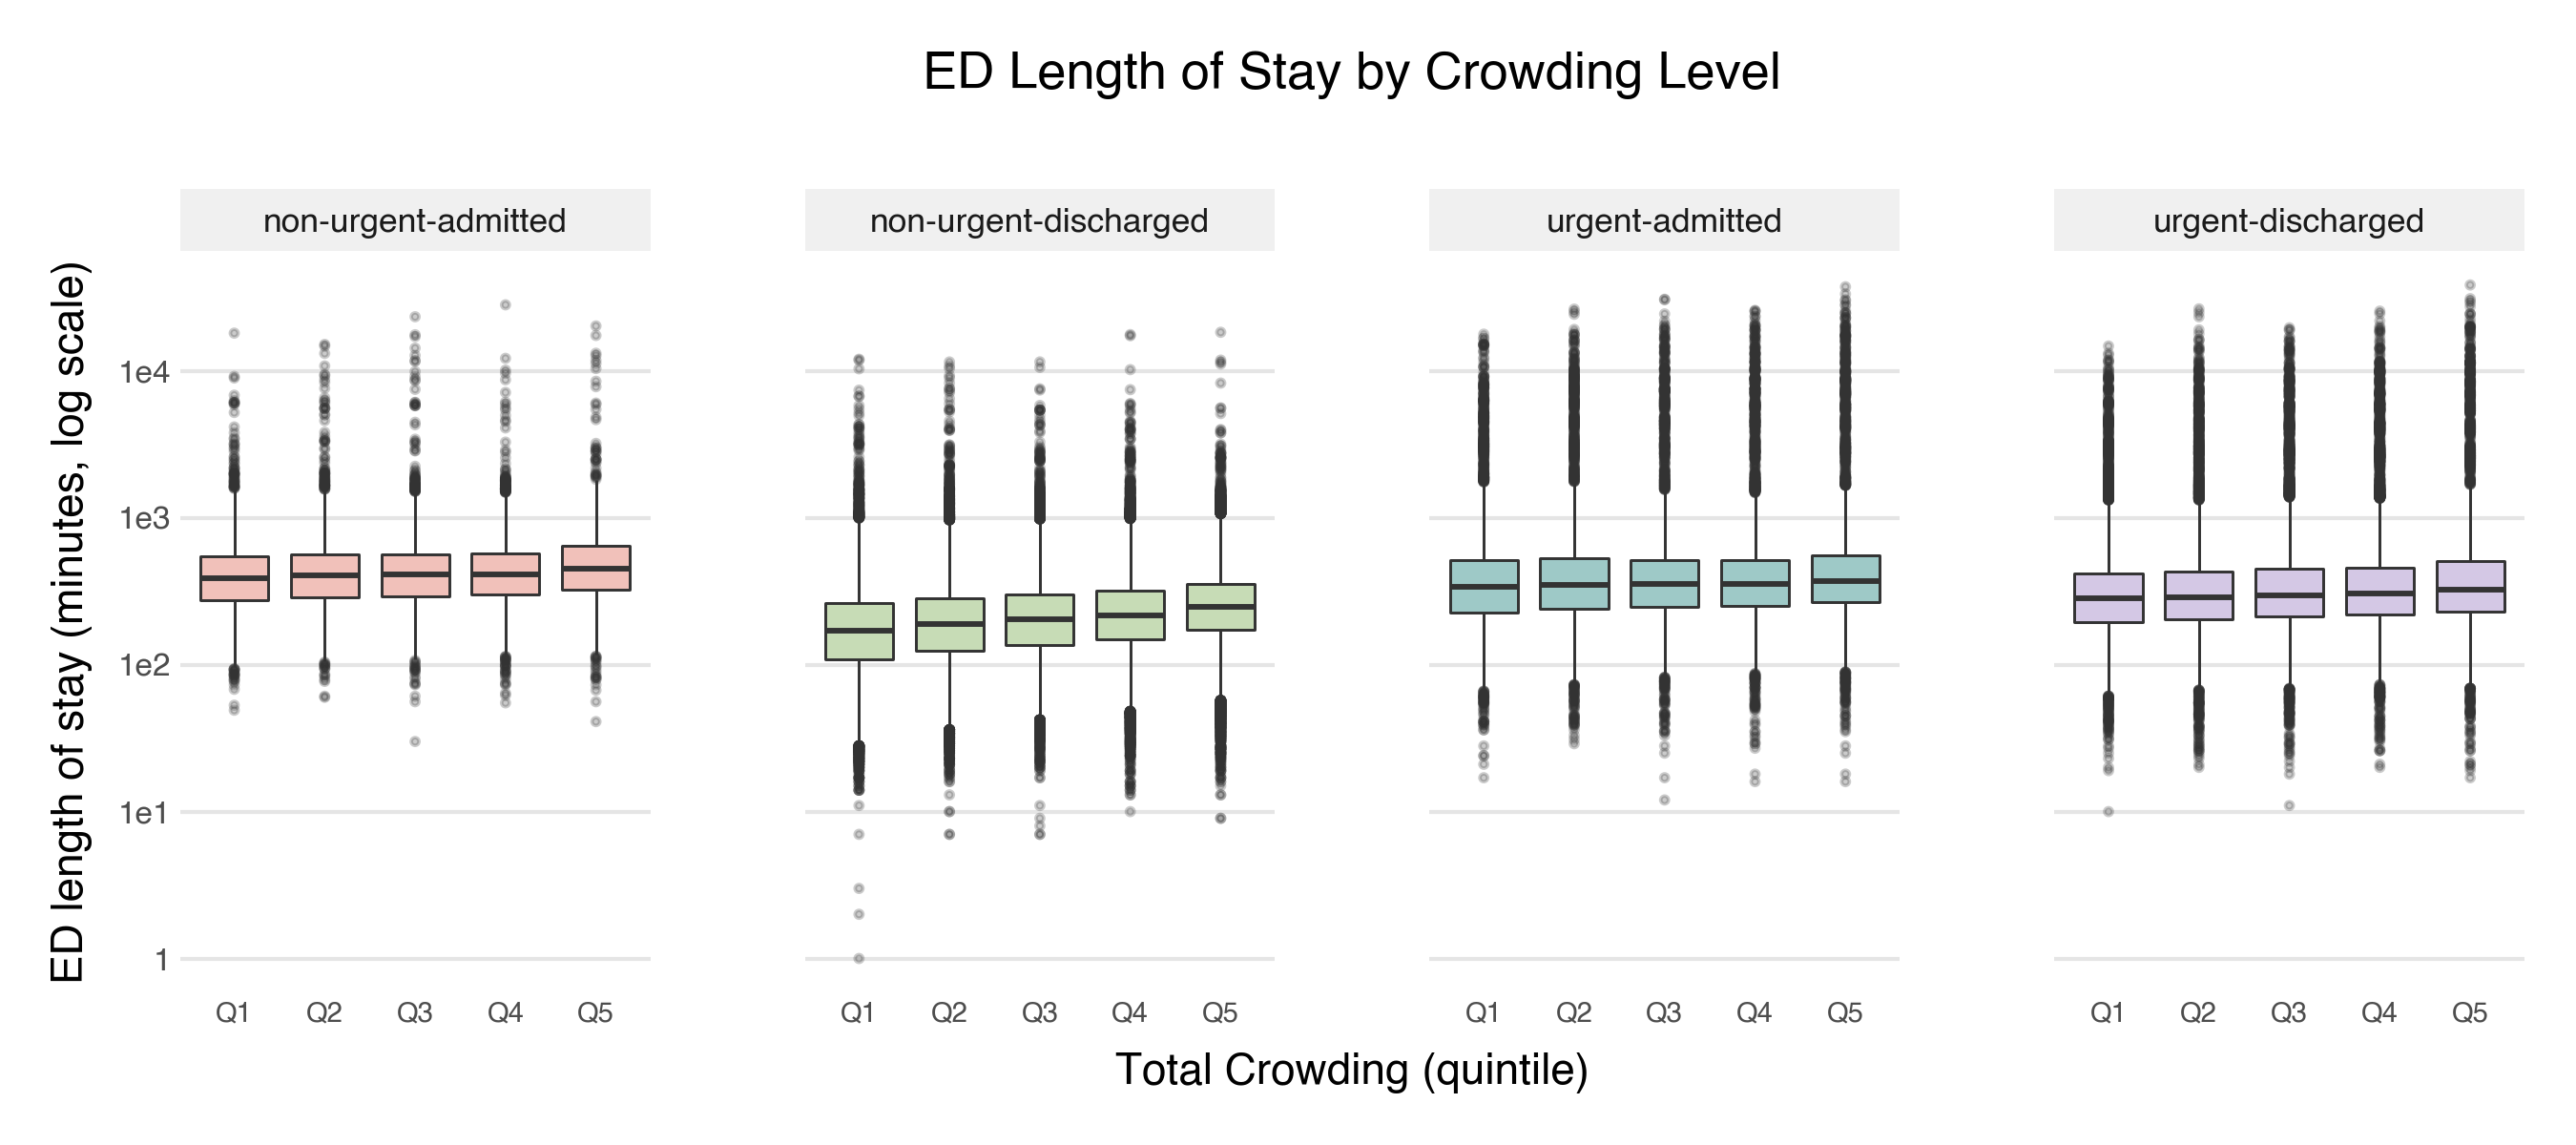

/opt/anaconda3/lib/python3.12/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


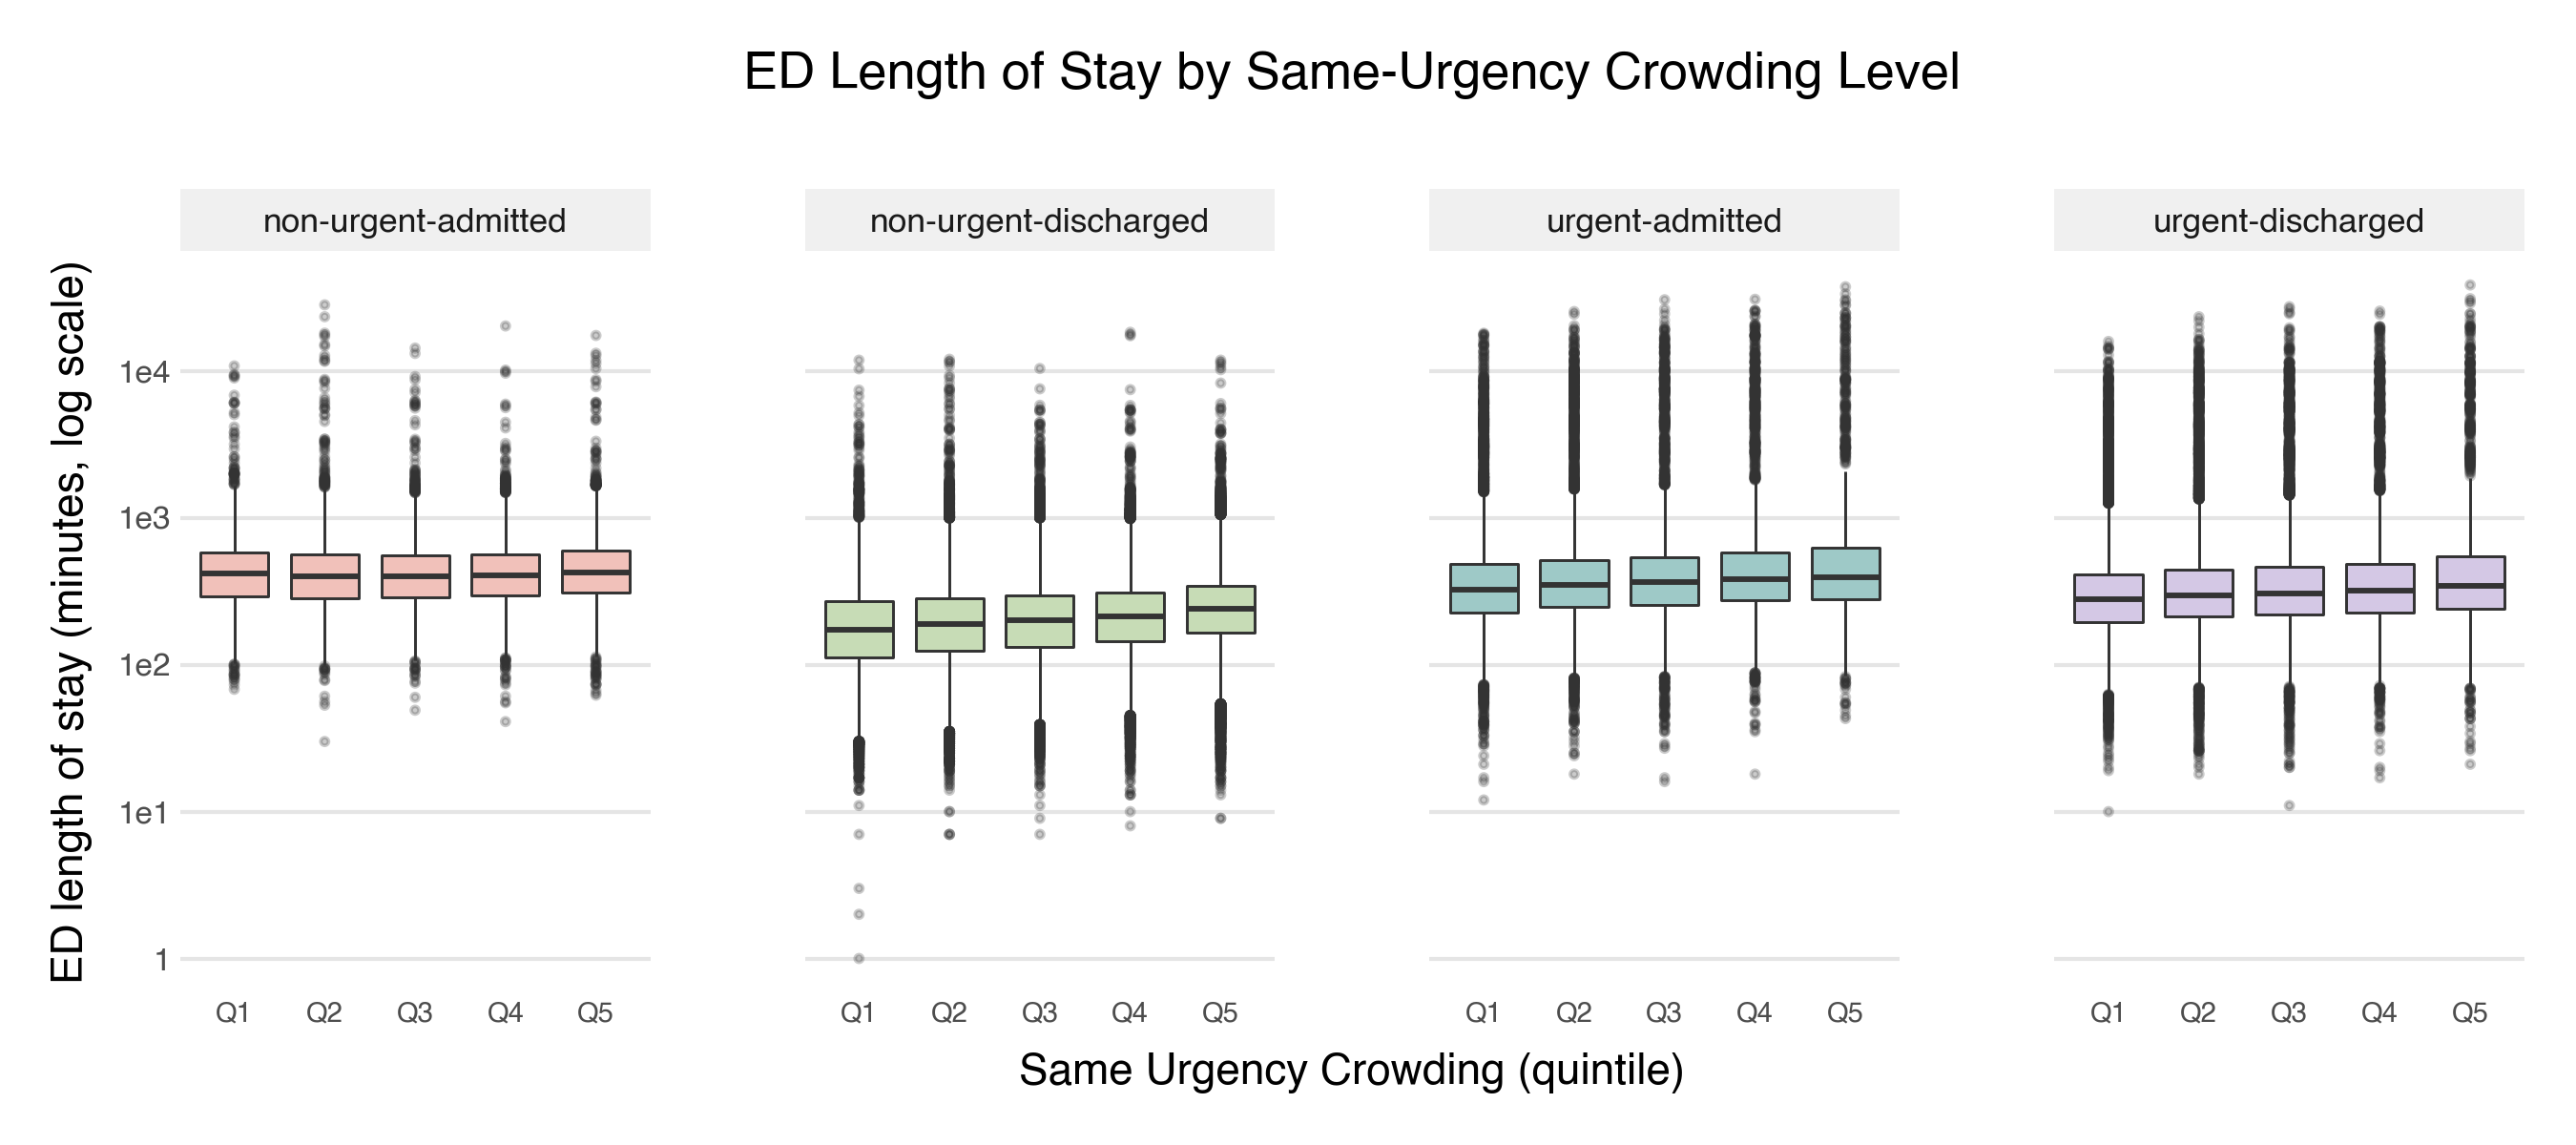

/opt/anaconda3/lib/python3.12/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


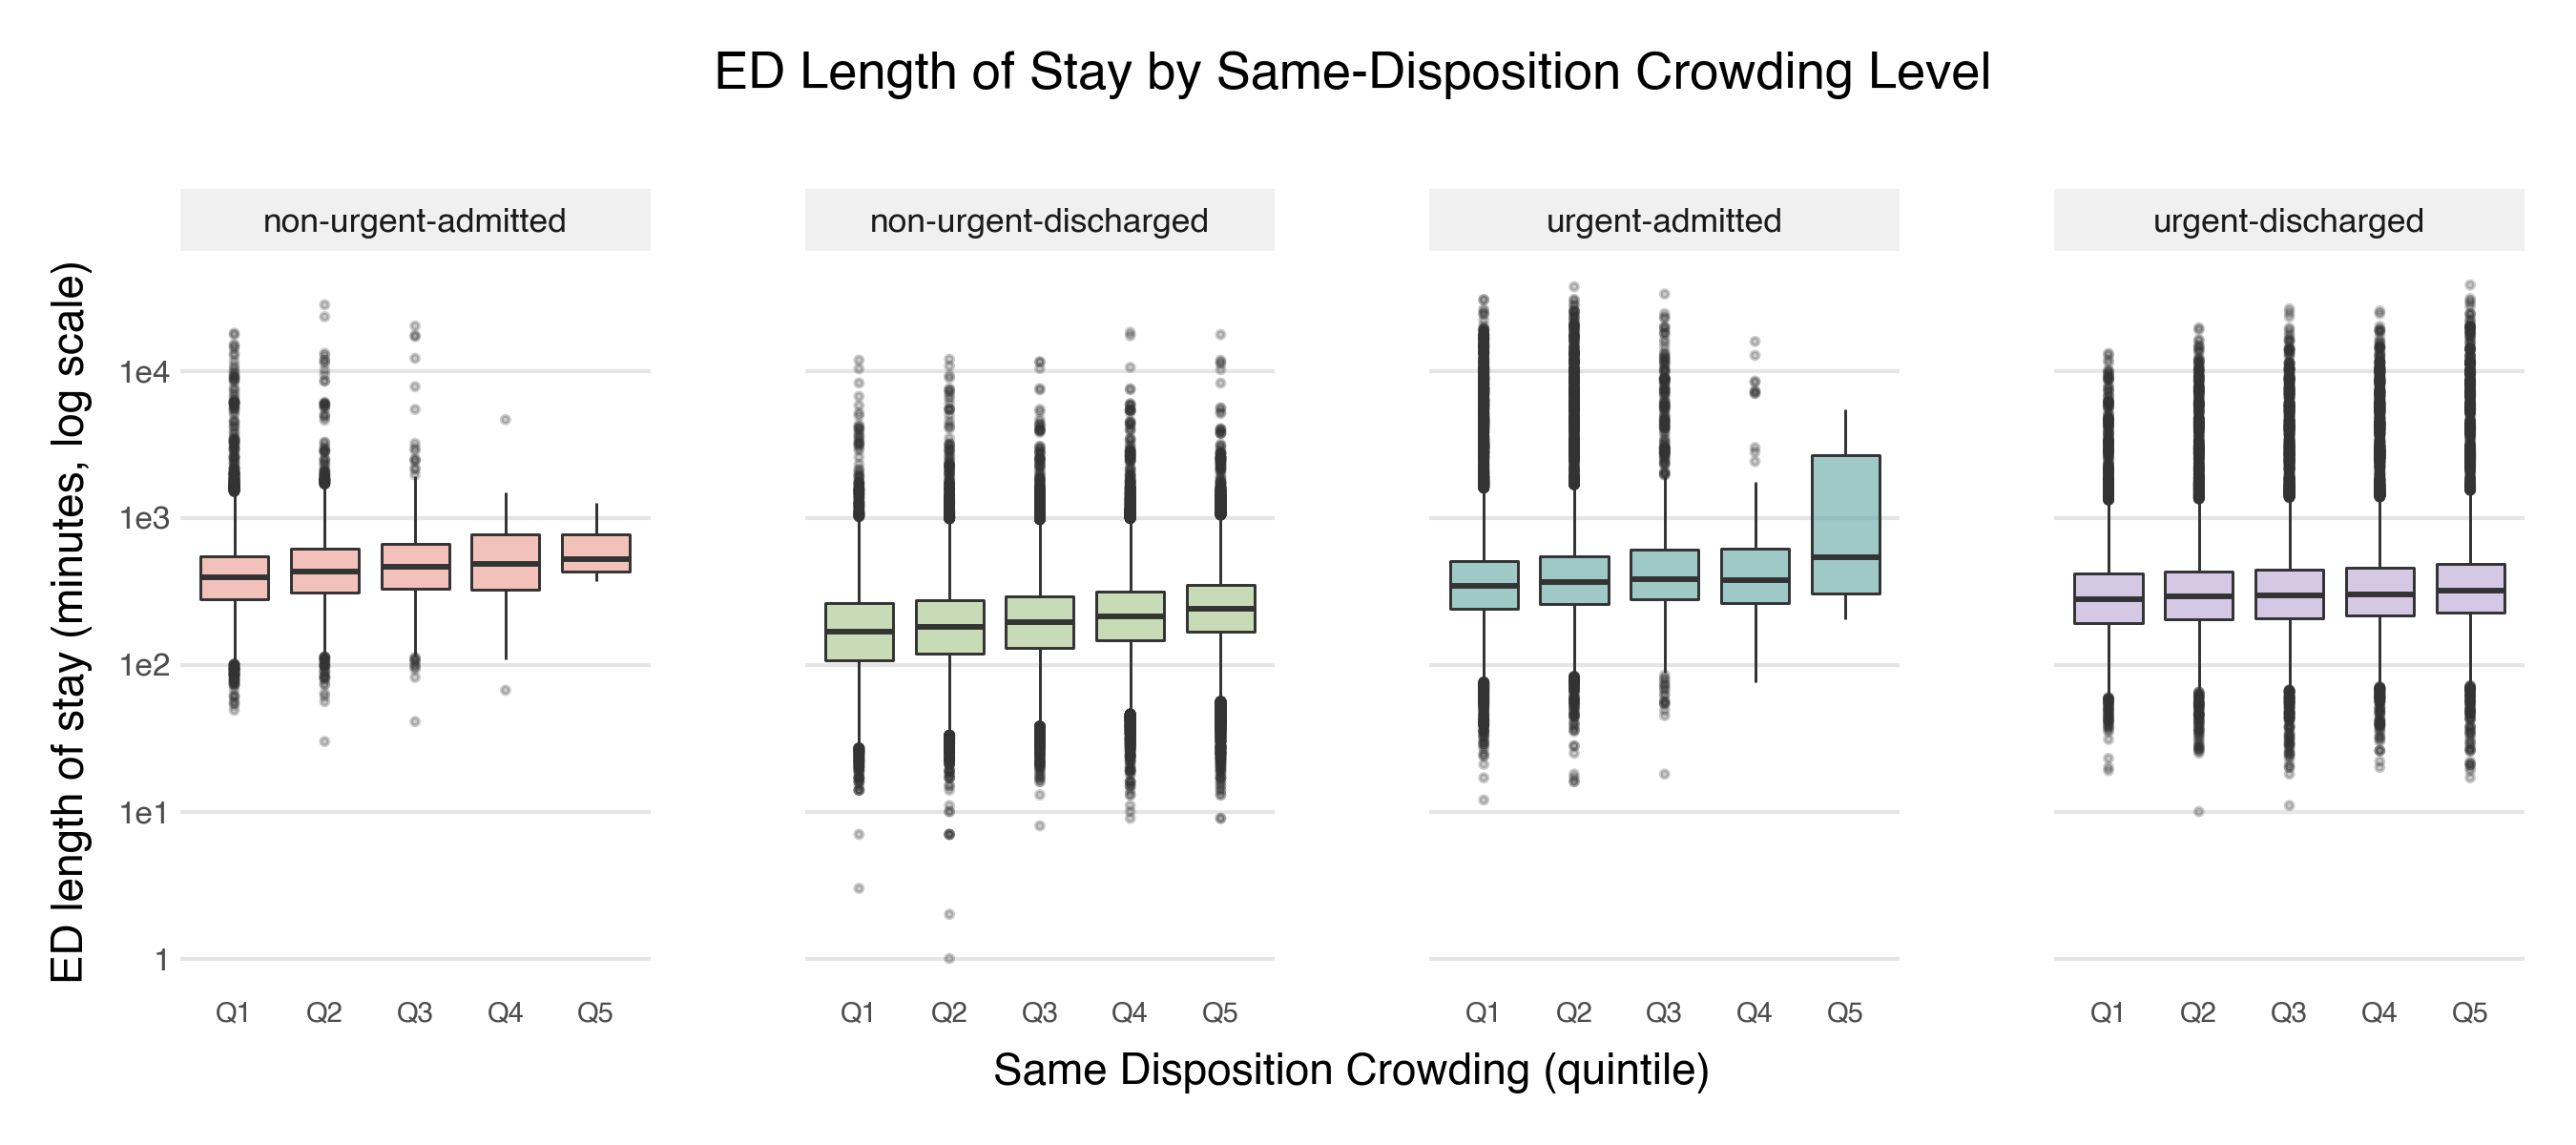

/opt/anaconda3/lib/python3.12/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


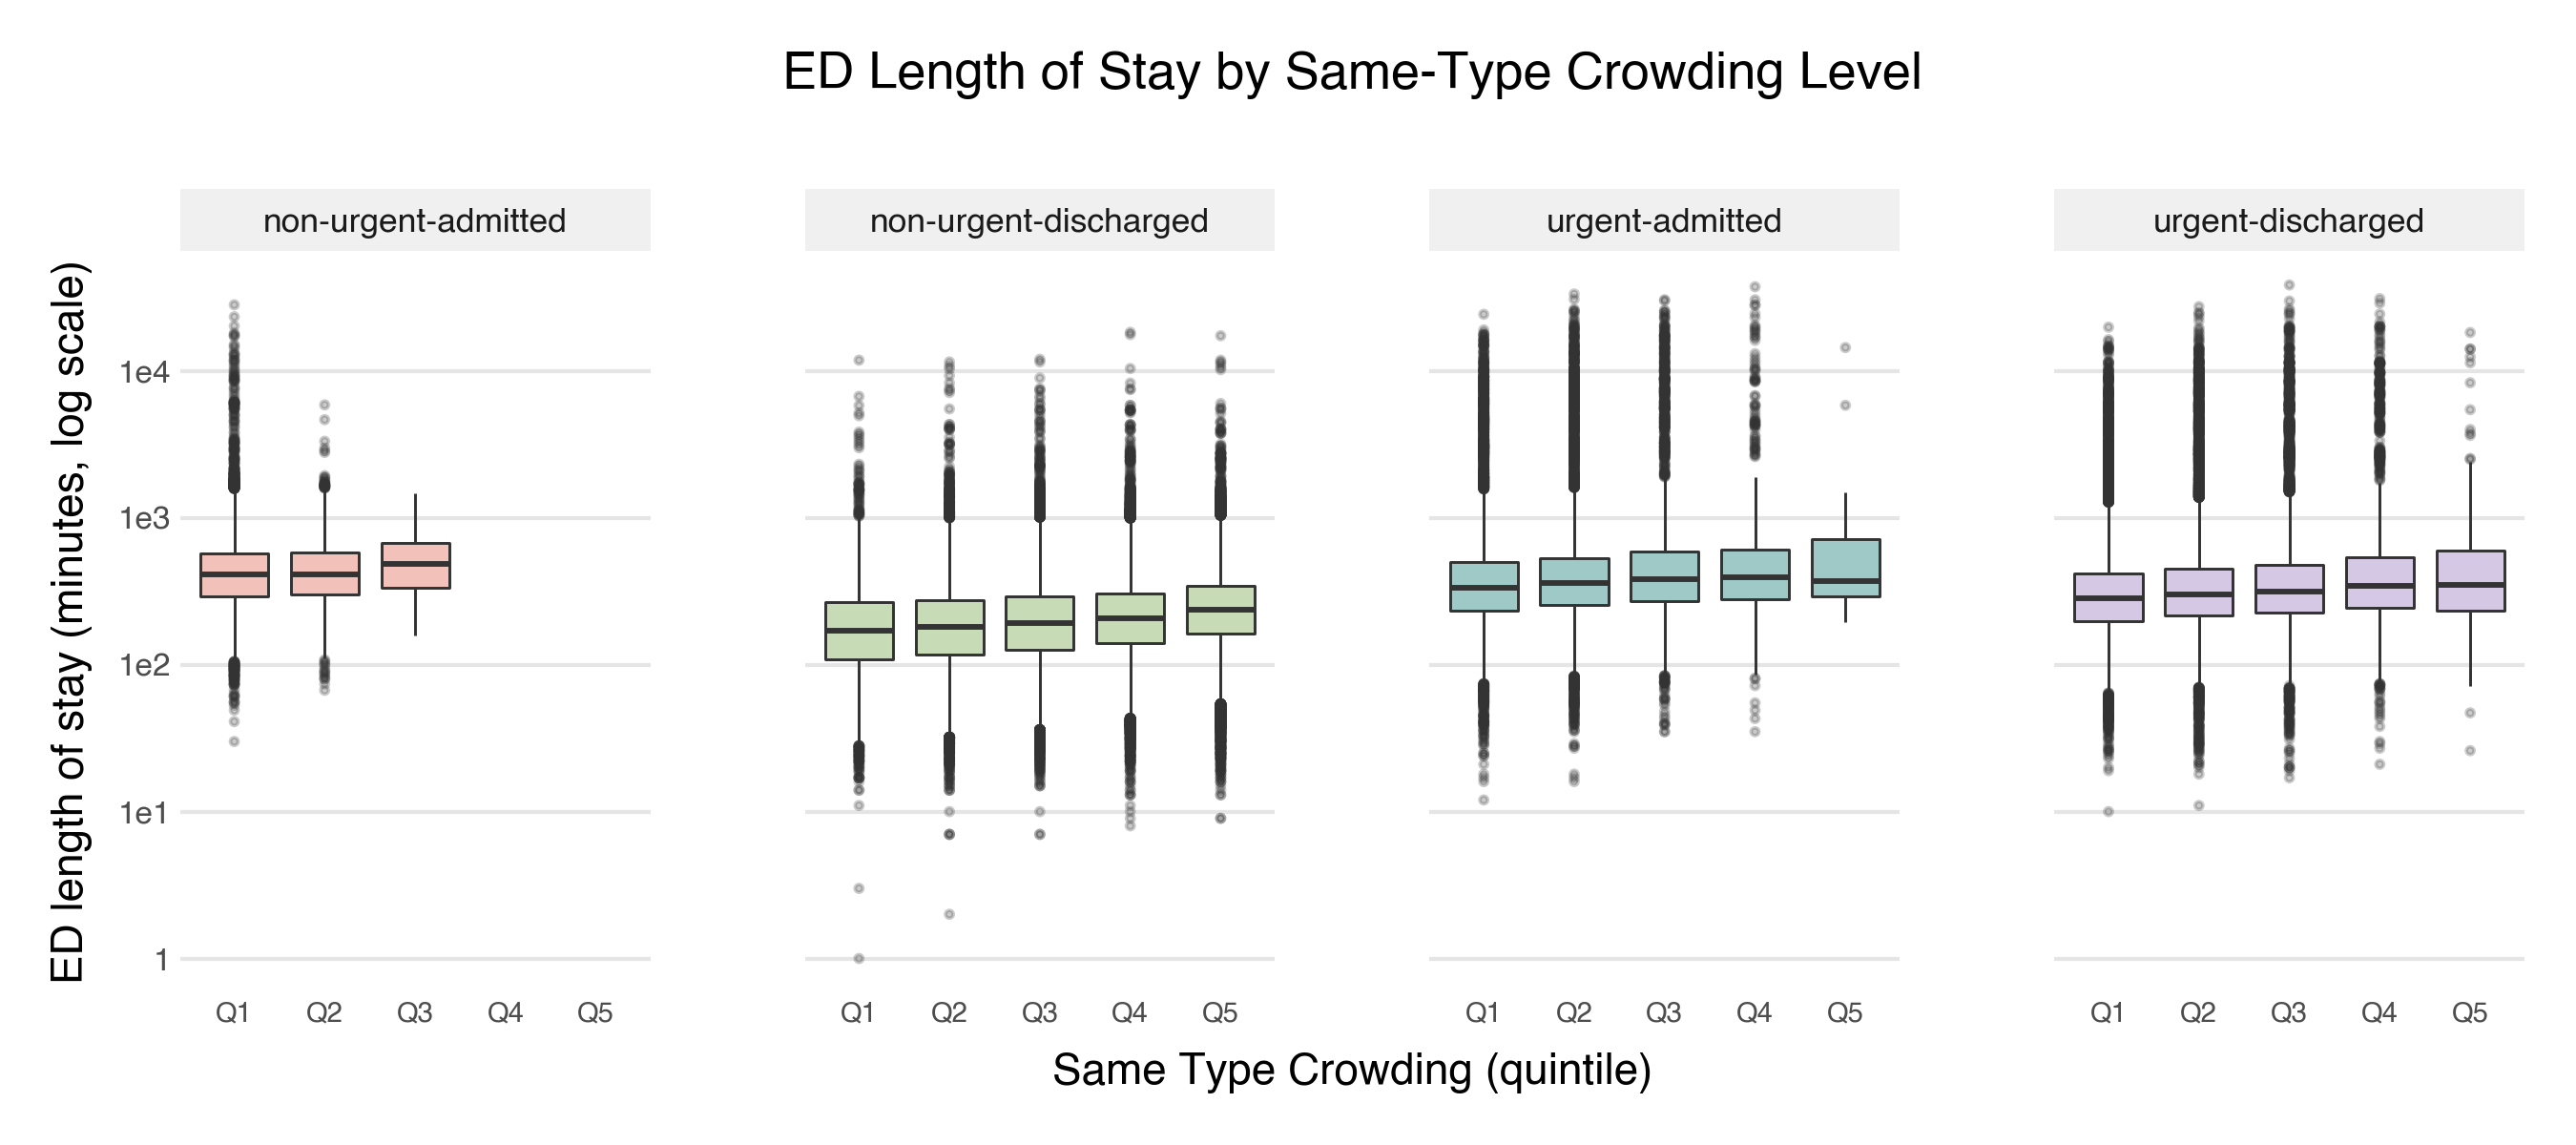

In [7]:
%matplotlib inline

import pandas as pd
import numpy as np
from plotnine import *

# # Load data
# visit_timeline = pd.read_csv(save_filepath + 'visit-timeline.csv', index_col=0)
# visit_timeline['log_ed_los'] = np.log(visit_timeline['ed_los'])
# visit_timeline['total-crowding'] = (
#     visit_timeline['non-urgent-admitted'] + visit_timeline['urgent-admitted']
#     + visit_timeline['urgent-discharged'] + visit_timeline['non-urgent-discharged']
# )

# #Collate crowding types.
# visit_timeline['urgent-crowding'] = visit_timeline['urgent-discharged'] + visit_timeline['urgent-admitted']
# visit_timeline['non-urgent-crowding'] = visit_timeline['non-urgent-admitted'] + visit_timeline['non-urgent-discharged']
# visit_timeline['admit-crowding'] = visit_timeline['urgent-discharged'] + visit_timeline['non-urgent-admitted']
# visit_timeline['discharge-crowding'] = visit_timeline['non-urgent-discharged'] + visit_timeline['urgent-discharged']
# visit_timeline['same-urgency-crowding'] = np.where(visit_timeline['visit_type'].isin(['urgent-admitted', 'urgent-discharged']), visit_timeline['urgent-crowding'], visit_timeline['non-urgent-crowding'])
# visit_timeline['same-disposition-crowding'] = np.where(visit_timeline['visit_type'].isin(['urgent-admitted', 'non-urgent-admitted']), visit_timeline['admit-crowding'], visit_timeline['discharge-crowding'])


# #Get crowding of the same type.
# crowding_cols = ['non-urgent-admitted', 'non-urgent-discharged', 'urgent-admitted', 'urgent-discharged']
# conditions = [visit_timeline['visit_type'] == c for c in crowding_cols]
# choices = [visit_timeline[c] for c in crowding_cols]
# visit_timeline['same-type-crowding'] = np.select(conditions, choices)

# #Save these.
# visit_timeline.to_csv(save_filepath + 'intermediate-files/visit-timeline-with-summed-crowding.csv')


#Load back data.
visit_timeline = pd.read_csv(save_filepath + 'intermediate-files/visit-timeline-with-summed-crowding.csv', index_col=0)

# Nicer palette (soft but distinct)
crowding_colors = {
    'non-urgent-admitted': '#E8998D',
    'non-urgent-discharged': '#A3C586',
    'urgent-admitted': '#5DA5A3',
    'urgent-discharged': '#B8A4D4',
}
def crowding_plot(df, crowding_type, title, bins=5):
    df_binned = df.copy()
    df_binned['crowding_binned'] = pd.qcut(
        df[crowding_type], q=bins,
        labels=[f'Q{i+1}' for i in range(bins)]
    )

    return (
        ggplot(df_binned, aes(x='crowding_binned', y='ed_los', fill='visit_type'))
        + geom_boxplot(alpha=0.6, outlier_size=0.6, outlier_alpha=0.25, size=0.4)
        + scale_y_log10()
        + scale_fill_manual(values=crowding_colors)
        + facet_grid('~ visit_type')
        + labs(
            title=title,
            y='ED length of stay (minutes, log scale)',
            x=f'{crowding_type.replace("-", " ").title()} (quintile)',
            fill=''
        )
        + theme_minimal(base_size=11)
        + theme(
            figure_size=(9, 4),          # was 10x4.5 — too wide relative to content
            dpi=150,
            plot_title=element_text(size=13, weight='bold', margin={'b': 10}),
            strip_text=element_text(size=8.5, weight='bold'),
            strip_background=element_rect(fill='#F0F0F0', color='none'),
            axis_text_x=element_text(size=7, rotation=0),  # Q1-Q5 short enough to stay horizontal
            axis_text_y=element_text(size=8),
            panel_spacing=0.06,           
            panel_grid_minor=element_blank(),
            panel_grid_major_x=element_blank(),
            legend_position='none',
            plot_margin=0.02,
            subplots_adjust={'right': 0.98},  # stop the last strip label clipping
        )
    )

#Illustrate responsiveness to overall crowding.
p = crowding_plot(visit_timeline, 'total-crowding', 'ED Length of Stay by Crowding Level')
p.show()

#Illustrate responsiveness to same-urgency crowding.
p = crowding_plot(visit_timeline, 'same-urgency-crowding', 'ED Length of Stay by Same-Urgency Crowding Level')
p.show()

#Illustrate responsiveness to same-urgency crowding.
p = crowding_plot(visit_timeline, 'same-disposition-crowding', 'ED Length of Stay by Same-Disposition Crowding Level')
p.show()

#Illustrate responsiveness to same-type crowding.
p = crowding_plot(visit_timeline, 'same-type-crowding', 'ED Length of Stay by Same-Type Crowding Level')
p.show()

In [21]:
visits = pd.read_csv(save_filepath + 'intermediate-files/visits.csv', index_col=0)

visits.columns.to_list()


/var/folders/f0/gwbmx5k5669ffg3gh0_5_k400000gn/T/ipykernel_63552/1580846947.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.


['csn',
 'mrn',
 'is_admitted',
 'minutes_since_first_arrival',
 'ed_los',
 'is_trans_or_nb',
 'is_weekend',
 'pre_diagnosis_any_malignancy',
 'pre_diagnosis_gastrointestinal',
 'pre_diagnosis_nausea_and_vomiting',
 'pre_diagnosis_diabetes_mellitus',
 'pre_diagnosis_pain_conditions',
 'pre_diagnosis_cardiovascular',
 'pre_diagnosis_developmental_delays',
 'pre_diagnosis_epilepsy',
 'pre_diagnosis_asthma',
 'pre_diagnosis_anemia',
 'pre_diagnosis_congenital_malformations',
 'pre_diagnosis_conduct_disorders',
 'pre_diagnosis_chromosomal_anomalies',
 'pre_diagnosis_anxiety',
 'pre_diagnosis_weight_loss',
 'pre_diagnosis_psychotic_disorders',
 'pre_diagnosis_drug_abuse',
 'pre_diagnosis_smoking',
 'pre_diagnosis_depression',
 'pre_diagnosis_eating_disorders',
 'pre_diagnosis_menstrual_disorders',
 'pre_diagnosis_sleep_disorders',
 'pre_diagnosis_joint_disorders',
 'pre_diagnosis_alcohol_abuse',
 'complaint_contains_abdominal_pain',
 'complaint_contains_assault',
 'complaint_contains_allerg

In [25]:
# --------------------------------------------------------------------------
# Age banding for age-specific vital-sign normalization.
#
# Pediatric vitals (HR, RR, BP, etc.) have very different normal ranges by
# age - a heart rate that's normal for a 2-month-old is a tachycardia for a
# 10-year-old. Z-scoring across the whole population would wash that out, so
# age-dependent columns get their mean/std/median computed WITHIN each band
# instead of globally. Bin edges are in days for exact, unambiguous cutoffs.
# --------------------------------------------------------------------------
DAYS_PER_MONTH = 30.4375   # 365.25 / 12, for unambiguous month cutoffs
DAYS_PER_YEAR = 365.25

AGE_BIN_EDGES_DAYS = [
    0,
    3 * DAYS_PER_MONTH,
    6 * DAYS_PER_MONTH,
    12 * DAYS_PER_MONTH,
    18 * DAYS_PER_MONTH,
    36 * DAYS_PER_MONTH,
    5 * DAYS_PER_YEAR,
    10 * DAYS_PER_YEAR,
    15 * DAYS_PER_YEAR,
    np.inf,
]
AGE_BIN_LABELS = [
    "0-3mo", "3-6mo", "6-12mo", "12-18mo", "18-36mo",
    "3-5y", "5-10y", "10-15y", "15+",
]
UNKNOWN_AGE_GROUP = "unknown"  # fallback bucket for missing/out-of-range ages



In [42]:
#Fit a log-normal model to each visit type.

#Load data and attach seasonality.
visit_timeline = pd.read_csv(save_filepath + 'intermediate-files/visit-timeline-with-summed-crowding.csv', index_col=0)
visits = pd.read_csv(save_filepath + 'intermediate-files/visits.csv', index_col=0)
visits = assign_age_group(visits, age_col='age_in_days') #Assign age group.


#Extract complaints.
complaints = ['complaint_contains_asthma_or_wheezing', 'complaint_contains_bites_or_stings', 
                              'complaint_contains_burn', 'complaint_contains_cardiac', 'complaint_contains_chest_pain', 
                              'complaint_contains_chronic_disease', 'complaint_contains_congestion', 'complaint_contains_constipation', 
                              'complaint_contains_cough', 'complaint_contains_croup', 'complaint_contains_crying_or_colic', 'complaint_contains_dental', 
                              'complaint_contains_device_complication', 'complaint_contains_diarrhea', 'complaint_contains_ear_complaint',
                                'complaint_contains_epistaxis', 'complaint_contains_extremity', 'complaint_contains_eye_complaint', 
                                'complaint_contains_syncope', 'complaint_contains_foreign_body', 'complaint_contains_fever', 
                                'complaint_contains_follow_up', 'complaint_contains_general', 'complaint_contains_gi_bleed',
                                  'complaint_contains_gynecologic', 'complaint_contains_head_or_neck', 'complaint_contains_headache', 
                                  'complaint_contains_laceration', 'complaint_contains_lump_or_mass', 'complaint_contains_male_genital', 
                                  'complaint_contains_mvc', 'complaint_contains_neck_pain', 'complaint_contains_neurologic', 
                                  'complaint_contains_poisoning', 'complaint_contains_poor_feeding', 'complaint_contains_pregnancy', 
                                  'complaint_contains_primary_care', 'complaint_contains_psych', 'complaint_contains_rash', 
                                  'complaint_contains_other_respiratory', 'complaint_contains_seizure', 'complaint_contains_sore_throat',
                                    'complaint_contains_trauma', 'complaint_contains_urinary', 'complaint_contains_vomiting']

preconditions = ['pre_diagnosis_any_malignancy', 'pre_diagnosis_gastrointestinal', 'pre_diagnosis_nausea_and_vomiting', 
                      'pre_diagnosis_diabetes_mellitus', 'pre_diagnosis_pain_conditions', 'pre_diagnosis_cardiovascular',
                        'pre_diagnosis_developmental_delays', 'pre_diagnosis_epilepsy', 'pre_diagnosis_asthma', 'pre_diagnosis_anemia', 
                        'pre_diagnosis_congenital_malformations', 'pre_diagnosis_conduct_disorders', 'pre_diagnosis_chromosomal_anomalies',
                          'pre_diagnosis_anxiety', 'pre_diagnosis_weight_loss', 'pre_diagnosis_psychotic_disorders', 'pre_diagnosis_drug_abuse',
                            'pre_diagnosis_smoking', 'pre_diagnosis_depression', 'pre_diagnosis_eating_disorders', 'pre_diagnosis_menstrual_disorders', 
                            'pre_diagnosis_sleep_disorders', 'pre_diagnosis_joint_disorders', 'pre_diagnosis_alcohol_abuse']

visit_timeline = visit_timeline.merge(visits[['csn', 'is_weekend', 'season', 'year_of_arrival', 'time_of_day',
                                              'age_group', 'insurance', 'ed_arrival_mode', 'language', 'race', 'sex',
                                              'physician_or_hospital_referral', 'miles_travelled', 'num_previous_admissions', 'num_previous_visits_without_admission'] +
                                              complaints + preconditions], on="csn", how='inner')

#We are interested in the effects of crowding on each model. Fit a model and control for chief complaint, miles travelled, age_
formula = "log_ed_los ~ is_weekend + C(season) + C(time_of_day) + C(year_of_arrival) " \
"+ C(ed_arrival_mode) + C(insurance) + C(language) + C(race) + C(sex) + C(age_group) + " \
"physician_or_hospital_referral + miles_travelled + num_previous_admissions + num_previous_visits_without_admission + " \
+ " + ".join(complaints) + " + " + " + ".join(preconditions) + " + C(visit_type)  + C(visit_type):(Q('non-urgent-discharged') + Q('urgent-admitted') + Q('urgent-discharged') + Q('non-urgent-admitted'))"

#Fit a single model in which everything interacts with visit-type.
model = smf.ols(formula, data=visit_timeline).fit()

ci = model.conf_int(alpha=0.05)
ci.columns = ['ci_lower', 'ci_upper']

summary_df = pd.DataFrame({
    'param': model.params.index,
    'exp(coef)': np.exp(model.params.values),
    'std_err': model.bse.values,
    'p_value': model.pvalues.values,
    'exp(ci_lower)': np.exp(ci['ci_lower'].values),
    'exp(ci_upper)': np.exp(ci['ci_upper'].values),
})

summary_df.to_csv(save_filepath + '/outputs/visit-type-crowding-lognormal-coeffs.csv')
summary_df


/var/folders/f0/gwbmx5k5669ffg3gh0_5_k400000gn/T/ipykernel_63552/4067052268.py:5: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.


,param,exp(coef),std_err,p_value,exp(ci_lower),exp(ci_upper)
0,Intercept,282.497079,0.022911,0.000000e+00,270.092097,295.471805
1,C(season)[T.spring],0.983971,0.003345,1.358261e-06,0.977542,0.990443
2,C(season)[T.summer],1.006869,0.003681,6.291836e-02,0.999631,1.014160
3,C(season)[T.winter],0.991336,0.003324,8.845639e-03,0.984899,0.997815
4,C(time_of_day)[T.evening],0.902910,0.002857,2.282245e-279,0.897869,0.907980
...,...,...,...,...,...,...
127,C(visit_type)[urgent-discharged]:Q('urgent-dis...,1.008434,0.000682,7.199349e-35,1.007087,1.009782
128,C(visit_type)[non-urgent-admitted]:Q('non-urge...,1.003390,0.001717,4.874462e-02,1.000019,1.006772
129,C(visit_type)[non-urgent-discharged]:Q('non-ur...,1.010646,0.000587,1.256754e-72,1.009483,1.011810
130,C(visit_type)[urgent-admitted]:Q('non-urgent-a...,1.004941,0.001465,7.682749e-04,1.002059,1.007831


In [43]:
#Load coefficients.
summary_df = pd.read_csv(save_filepath + '/outputs/visit-type-crowding-lognormal-coeffs.csv', index_col=0)

#Isolate coefficients of interest.
params_of_interest = summary_df[summary_df['param'].str.contains('urgent') | summary_df['param'].str.contains('admitted') | summary_df['param'].str.contains('discharged')].copy().reset_index(drop=True)

params_of_interest['ED LOS Change [Est.]'] = params_of_interest['exp(coef)']-1
params_of_interest['ED LOS Change [LC]'] = params_of_interest['exp(ci_lower)']-1
params_of_interest['ED LOS Change [UC]'] = params_of_interest['exp(ci_upper)']-1

params_of_interest

,param,exp(coef),std_err,p_value,exp(ci_lower),exp(ci_upper),ED LOS Change [Est.],ED LOS Change [LC],ED LOS Change [UC]
0,C(visit_type)[T.non-urgent-discharged],0.439579,0.012755,0.000000e+00,0.428726,0.450706,-0.560421,-0.571274,-0.549294
1,C(visit_type)[T.urgent-admitted],0.885379,0.016064,3.511112e-14,0.857937,0.913699,-0.114621,-0.142063,-0.086301
2,C(visit_type)[T.urgent-discharged],0.685880,0.015214,1.829978e-135,0.665730,0.706639,-0.314120,-0.334270,-0.293361
3,C(visit_type)[non-urgent-admitted]:Q('non-urge...,1.002072,0.000550,1.685299e-04,1.000992,1.003153,0.002072,0.000992,0.003153
4,C(visit_type)[non-urgent-discharged]:Q('non-ur...,1.011841,0.000192,0.000000e+00,1.011460,1.012222,0.011841,0.011460,0.012222
5,C(visit_type)[urgent-admitted]:Q('non-urgent-d...,0.999314,0.000461,1.367295e-01,0.998411,1.000218,-0.000686,-0.001589,0.000218
6,C(visit_type)[urgent-discharged]:Q('non-urgent...,1.004040,0.000385,1.125656e-25,1.003283,1.004797,0.004040,0.003283,0.004797
7,C(visit_type)[non-urgent-admitted]:Q('urgent-a...,1.006731,0.001115,1.754951e-09,1.004535,1.008933,0.006731,0.004535,0.008933
8,C(visit_type)[non-urgent-discharged]:Q('urgent...,1.007302,0.000385,1.916161e-79,1.006541,1.008063,0.007302,0.006541,0.008063
9,C(visit_type)[urgent-admitted]:Q('urgent-admit...,1.014530,0.000937,1.887393e-53,1.012668,1.016395,0.014530,0.012668,0.016395
